# Preprocessing x sensor placement -> latent space

What the AER sees is `client_datasets` -> `preprocess_clients` -> `(N, W, F)` windows. Two things
upstream of that were unexamined: **where** the channels come from (placement, never wired into
the FL path) and **what** is done to them in time.

| block | question | trains? |
|---|---|---|
| SS.2-4 | what am I feeding the model | no |
| SS.5 | which signal component does each transform keep (level / amplitude / shape) | no |
| SS.6-10 | grid `placement x preprocessing`, scored on latent + drift | yes |
| SS.11 | does the ranking replicate across worlds | yes |
| SS.12 | latent space, per placement, per round | no |
| SS.13-14 | client similarity and clustering, **init vs final** phase | no |

`preprocess_clients` and `FPLTrainer` are imported, never re-implemented; placement enters as a
column selection, no re-simulation; ground truth enters at scoring time only.

**Metric decisions this version encodes** (from the runs so far):

- Similarity structure is read as **`regime_gap`** (within- minus between-regime mean similarity),
  continuous, against its own **label-shuffle null**. ARI is kept as a secondary column only: with
  5 clients and 2 regime tokens it takes ~8 discrete values, so it mangles real movement.
- **`mean_offdiag` is dropped.** After `_deconfounded_prototypes` the client vectors are
  near-centered, which pins the mean off-diagonal cosine at about `-1/(N-1)`. It measured a
  constant. Degeneracy is now flagged by *low spread* (`sd_offdiag`).
- **Only the `dom` (prototype) channel is scored.** `delta_first` is ~0 in the first months, so
  `S_drift` and any fusion containing it are noise in the `init` phase.
- **Migration is one sanity column, not a section** (SS.13): the cluster-crossing test had no
  power -- most clients "moved" every round because the clustering was re-cut on a near-identical
  matrix (`rank_stability` up to 1.00). What survives is denominator-free: does the mover's
  similarity shift rank first among clients.
- Every p-value here has a **floor of 1/n_assignments** (0.10 for 5 clients / 2 tokens). Rank by
  effect size; significance needs a 3-token world.

## 0. Setup

In [1]:
from __future__ import annotations
import copy, itertools, json, pathlib, sys, time, warnings

import numpy as np, pandas as pd, torch, yaml
warnings.filterwarnings("ignore")

HERE = pathlib.Path.cwd().resolve()
ROOT = next((p for p in [HERE, *HERE.parents]
             if (p / "conf" / "base" / "parameters.yml").exists()
             and (p / "src" / "fedwater").is_dir()), None)
assert ROOT is not None, "run this from inside the fedwater repo (notebooks/...)"
for p in (ROOT / "src", ROOT / "notebooks", ROOT, HERE):
    if p.exists() and str(p) not in sys.path:
        sys.path.insert(0, str(p))

from notebooks.SensorPlacement import placement_poc as P     
from fedwater.pipelines.fl_preprocessing.nodes import preprocess_clients
from fedwater.pipelines.fl_training.federated import FPLTrainer
from fedwater.pipelines.fl_training.nodes import effective_fl_seed
from fedwater.pipelines.drift_detection.nodes import compute_drift_signals
from fedwater.pipelines.dependence_oracle.nodes import deseasonalize

BASE_PARAMS = yaml.safe_load((ROOT / "conf" / "base" / "parameters.yml").read_text())
SEED   = BASE_PARAMS.get("seed", 42)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SANDBOX = HERE / "latent_sandbox"; SANDBOX.mkdir(exist_ok=True)
pd.set_option("display.width", 170)

print(f"root {ROOT}\ndevice {DEVICE}  seed {SEED}  sandbox {SANDBOX}")

root C:\Users\arthu\USPy\10_Mestrado\fedWater
device cuda  seed 42  sandbox C:\Users\arthu\USPy\10_Mestrado\fedWater\notebooks\prospection\latent_sandbox


## 1. World and configuration

`discover_worlds` reads the experiments cache directly. Only `baseline` worlds are used: under
`partial`/`isolated` a topology-driven placement sees the same pipes the labels come from.

In [2]:
index = P.discover_worlds(ROOT)
assert len(index) and index["usable"].any(), "no usable cached worlds"
usable = index[index["usable"] & (index["variant"] == "baseline")]
display(usable[["tag", "sim_seed", "consumption_map", "n_months", "drift_district"]]
        .reset_index(drop=True))


# --- manifests are not guaranteed complete: any of resolution_h / n_months /
# --- days_per_month can be None, and `int(None)` then kills every cell in the world.
# --- Everything downstream (including preprocess_clients, which receives TIME) reads
# --- the coerced dict, so the repair happens once, here.
def _num(x, default=None):
    v = pd.to_numeric(x, errors="coerce")
    return default if pd.isna(v) else float(v)


def world_time(art: dict) -> dict:
    """`params.time` with every field numeric, recovered from the artifacts if absent."""
    t = dict(art["params"].get("time", {}) or {})
    res = _num(t.get("resolution_h"))
    if res is None or res <= 0:
        res = 24.0 / max(1.0, _num(art.get("steps_day"), 24.0))
    dpm = _num(t.get("days_per_month"), 30.0) or 30.0
    n = _num(t.get("n_months"))
    if n is None or n <= 0:                       # count it off the simulated horizon
        spm = max(1.0, (24.0 / res) * dpm)
        n = max(1.0, round(len(art["pressures"]) / spm))
    t.update(resolution_h=(int(res) if float(res).is_integer() else res),
             days_per_month=int(dpm), n_months=int(n))
    return t


def drift_start(world_dir, n_months=None) -> int:
    """First drifted month from gt_drift_schedule; midpoint if absent; 0 if unknowable."""
    f = pathlib.Path(world_dir) / "clone" / "data" / "03_primary" / "gt_drift_schedule.csv"
    if f.exists():
        try:
            d = pd.read_csv(f)
            col = next((c for c in d.columns if "month" in c.lower()), None)
            if col is not None and len(d):
                v = pd.to_numeric(d[col], errors="coerce").dropna()
                if len(v):
                    return int(v.min())
        except Exception:
            pass
    n = _num(n_months)
    return int(n) // 2 if n and n > 0 else 0


def world_fl(art: dict) -> dict:
    """`params.fl` with the fields we index numeric, and the device pinned."""
    fl = copy.deepcopy(art["params"].get("fl", BASE_PARAMS["fl"]))
    tr, pp = fl.setdefault("training", {}), fl.setdefault("preprocessing", {})
    tr["device"] = DEVICE
    for k, dflt in (("rounds", 15), ("local_epochs", 1), ("batch_size", 64)):
        tr[k] = int(_num(tr.get(k), dflt))
    for k, dflt in (("interval_agg_h", 2), ("window_size", 24), ("step_size", 6),
                    ("reference_months", 2)):
        pp[k] = int(_num(pp.get(k), dflt))
    return fl


WORLD = usable.iloc[-1]                       # <- the single-world study
ART   = P.load_world(WORLD["dir"])
TIME  = world_time(ART)
STEPS_DAY    = int(_num(ART.get("steps_day"), 24.0 / TIME["resolution_h"]))
FL_BASE      = world_fl(ART)
TRUTH_CLIENT = WORLD.get("drift_district")
DRIFT_START  = drift_start(WORLD["dir"], TIME["n_months"])
CURRENT_WORLD = WORLD["sim_hash"]            # which world CLIENTS/ART currently hold

print(f"{WORLD['tag']}  |  drift {TRUTH_CLIENT} from month {DRIFT_START}  |  "
      f"{TIME['n_months']} months @ {TIME['resolution_h']}h  |  steps/day {STEPS_DAY}")
raw_time = ART["params"].get("time", {}) or {}
if any(raw_time.get(k) is None for k in ("resolution_h", "days_per_month", "n_months")):
    print("  NOTE manifest had None in params.time "
          f"({ {k: raw_time.get(k) for k in ('resolution_h', 'days_per_month', 'n_months')} })"
          " -- values above were recovered from the artifacts")

,tag,sim_seed,consumption_map,n_months,drift_district
0,Clr__LR_LI_LI_LR_LI__baseline,42,LR_LI_LI_LR_LI,30,District_C
1,Dli__LI_LR_LI_LR_LI__baseline,42,LI_LR_LI_LR_LI,30,District_D
2,Bli__LI_LR_LI_LR_LI__baseline,42,LI_LR_LI_LR_LI,30,District_B
3,Ali__LR_LI_LI_LR_LI__baseline,42,LR_LI_LI_LR_LI,30,District_A
4,Blr__LR_LI_LI_LR_LI__baseline,42,LR_LI_LI_LR_LI,30,District_B
5,Elr__LI_LR_LI_LR_LI__baseline,42,LI_LR_LI_LR_LI,30,District_E
6,Blr__LI_LI_LR_LR_LR__baseline,42,LI_LI_LR_LR_LR,30,District_B
7,Alr__LI_LI_LR_LR_LR__baseline,42,LI_LI_LR_LR_LR,30,District_A
8,Dli__LR_LI_LI_LR_LI__baseline,42,LR_LI_LI_LR_LI,30,District_D
9,Clr__LI_LR_LI_LR_LI__baseline,42,LI_LR_LI_LR_LI,30,District_C


Dli__LI_LR_LR_LR_LI__baseline  |  drift District_D from month 6  |  30 months @ 1h  |  steps/day 24


## 2. Placement -> client datasets

`strategies()` returns a placement per rule; `build_series()` turns it into the sensor long frame.
The only new code is the repackaging into the wide `District_*.csv` schema
(`timestamp, month, p_*, q_*`) that `preprocess_clients` consumes -- this is the join that was
missing between the placement POC and the FL stack.

In [6]:
STRATEGIES = ["manual", "variance", "boundary"]      # per the placement POC finding

cands       = P.candidate_table(ART["wn"], ART["districts"])
feats, dist = P.topology_features(ART["wn"], ART["districts"], cands)
stats       = P.residual_stats(ART["pressures"], ART["flows"], cands, STEPS_DAY)
PLACEMENTS  = {k: v for k, v in
               P.strategies(cands, feats, stats, dist, ART["params"], seed=SEED).items()
               if k in STRATEGIES}


def clients_from_placement(art, placement, noise=False, seed=SEED,
                           kinds=None) -> dict[str, pd.DataFrame]:
    """placement -> {district: wide frame} in the client_datasets schema.

    kinds: subset of {"pressure","flow"} to keep (filters AFTER selection -- the candidates
    still competed under the full 2p+3q template). None keeps everything.
    """
    ss = P.build_series(art["pressures"], art["flows"], placement,
                        art["params"]["noise"] if noise else None, seed)
    if kinds:
        ss = ss[ss["kind"].isin(kinds)]
    wide  = ss.pivot(index="step", columns="sensor", values="observed").sort_index()
    month = ss.drop_duplicates("step").set_index("step")["month"].sort_index()
    key   = ss.drop_duplicates("sensor").set_index("sensor")["district"]
    res_h = world_time(art)["resolution_h"]          # coerced: manifests carry None
    ts    = pd.date_range("2020-01-01", periods=len(wide),
                          freq=f"{max(1, int(round(float(res_h))))}h")

    out = {}
    for d, grp in key.groupby(key):
        cols = sorted(grp.index)                       # p_* then q_*, stable across clients
        f = wide[cols].copy().reset_index(drop=True)
        f.insert(0, "month", month.to_numpy())
        f.insert(0, "timestamp", ts)
        out[d] = f
    return out


def assert_equal_channels(clients: dict[str, pd.DataFrame]):
    """FedAvg needs identical architectures -- every client must carry the same channel count."""
    n = {c: len([x for x in f.columns if x not in ("timestamp", "month")])
         for c, f in clients.items()}
    if len(set(n.values())) > 1:
        raise AssertionError(f"channel count differs across clients (breaks FedAvg): {n}")


CLIENTS = {s: clients_from_placement(ART, pl, kinds=("flow",)) for s, pl in PLACEMENTS.items()}
# CLIENTS = {s: clients_from_placement(ART, pl, kinds=("flow",))          # flow-only, 3 channels
#            for s, pl in PLACEMENTS.items()}
for s, frames in CLIENTS.items():
    assert_equal_channels(frames)

CHANNELS = {s: {c: [x for x in f.columns if x not in ("timestamp", "month")]
                for c, f in d.items()} for s, d in CLIENTS.items()}
pd.DataFrame({s: {c: ",".join(v) for c, v in ch.items()} for s, ch in CHANNELS.items()})

,manual,variance,boundary
District_A,"q_100,q_102,q_85","q_102,q_103,q_136","q_103,q_104,q_176"
District_B,"q_135,q_157,q_165","q_129,q_131,q_134","q_133,q_134,q_136"
District_C,"q_110,q_119,q_91","q_104,q_119,q_97","q_129,q_95,q_97"
District_D,"q_38,q_69,q_96","q_45,q_94,q_96","q_44,q_69,q_96"
District_E,"q_11,q_19,q_59","q_145,q_53,q_67","q_181,q_65,q_67"


## 3. The preprocessing stack

Two insertion points, deliberately kept apart:

* **before windowing** -- a transform on the client frame (`none | slog | diff | deseason_own |
  deseason_shared`). `preprocess_clients` then runs verbatim on the transformed frame.
* **after windowing** -- the scaling axis. `preprocess_clients` always fits a per-client MinMax
  on the commissioning months; `rescale_windows` inverts that affine map with `fl_scalers` and
  re-applies whatever we asked for, so `none` (physical units) and `zscore` are reachable
  without forking pipeline code.

In [7]:
def _cell_index(n, steps_day, month):
    day = np.arange(n) // steps_day
    return pd.DataFrame({"month": np.asarray(month), "hour": np.arange(n) % steps_day,
                         "weekend": (day % 7) >= 5})


def _slog(x):                       # flows are signed -- log1p on the magnitude
    return np.sign(x) * np.log1p(np.abs(x))


def deseason_shared(frames: dict, steps_day: int, k: int = 4) -> dict:
    """Remove the top-k PCs of the POOLED (month,hour,weekend) profile matrix.

    Each component is mean-zero across cells by construction, so a channel's own LEVEL
    survives -- the difference from `deseason_own`, which subtracts each channel's own cell
    means and therefore deletes exactly the level ladder the regime codes assert.
    """
    cols = {c: [x for x in f.columns if x not in ("timestamp", "month")] for c, f in frames.items()}
    any_f = next(iter(frames.values()))
    cells = _cell_index(len(any_f), steps_day, any_f["month"].to_numpy())
    gid = cells.groupby(["month", "hour", "weekend"], sort=True).ngroup().to_numpy()
    ncell = gid.max() + 1

    stack, names = [], []
    for c, f in frames.items():
        for x in cols[c]:
            v = f[x].to_numpy(float)
            stack.append(np.bincount(gid, v, ncell) / np.bincount(gid, minlength=ncell))
            names.append((c, x))
    Pm = np.column_stack(stack)                              # cells x channels
    mu, sd = Pm.mean(0), Pm.std(0, ddof=0)
    Z = (Pm - mu) / np.where(sd > 0, sd, 1.0)
    U, _, _ = np.linalg.svd(Z, full_matrices=False)
    B = U[:, :k]
    fitted = (B @ (B.T @ Z)) * np.where(sd > 0, sd, 1.0)     # channel units, mean-zero over cells

    out = {c: f.copy() for c, f in frames.items()}
    for j, (c, x) in enumerate(names):
        out[c][x] = out[c][x].to_numpy(float) - fitted[gid, j]
    return out


def apply_transform(frames: dict, name: str, steps_day: int) -> dict:
    if name == "none":
        return frames
    if name == "deseason_shared":
        return deseason_shared(frames, steps_day)
    out = {}
    for c, f in frames.items():
        g = f.copy()
        cols = [x for x in g.columns if x not in ("timestamp", "month")]
        if name == "slog":
            g[cols] = _slog(g[cols].to_numpy(float))
        elif name == "diff":
            g[cols] = g[cols].diff().fillna(0.0)
        elif name == "deseason_own":            # fedwater invariant 5, month-aware
            wide = g[cols].copy()
            wide.index = np.arange(len(g))
            res = deseasonalize(wide, steps_day, g["month"].copy(), month_aware=True)
            g[cols] = np.asarray(res)
        else:
            raise KeyError(name)
        out[c] = g
    return out


TRANSFORMS = ["none", "slog", "diff", "deseason_own", "deseason_shared"]

In [8]:
def _scaler_bounds(scalers: pd.DataFrame, client: str, sensors) -> tuple[np.ndarray, np.ndarray]:
    """(min, max) per channel from fl_scalers, whatever it calls its columns."""
    low = {c.lower(): c for c in scalers.columns}
    ccol = next(low[k] for k in ("district", "client", "partition", "name") if k in low)
    scol = next(low[k] for k in ("sensor", "feature", "channel", "column") if k in low)
    mncol = next(c for c in scalers.columns if "min" in c.lower())
    mxcol = next(c for c in scalers.columns if "max" in c.lower())
    g = scalers[scalers[ccol] == client].drop_duplicates(scol).set_index(scol)
    return (g.loc[list(sensors), mncol].to_numpy(float),
            g.loc[list(sensors), mxcol].to_numpy(float))


def rescale_windows(fl_windows: dict, scalers: pd.DataFrame, mode: str, fl: dict) -> dict:
    """minmax_ref (as-is) | none (physical units) | zscore (per client-channel)."""
    if mode == "minmax_ref":
        return fl_windows
    lo, hi = fl["preprocessing"]["feature_range"]
    out = {}
    for c, d in fl_windows.items():
        mn, mx = _scaler_bounds(scalers, c, d["sensors"])
        raw = (d["windows"].astype(np.float64) - lo) / (hi - lo) * (mx - mn) + mn
        if mode == "none":
            w = raw
        elif mode == "zscore":
            ref = d["labels"] < fl["preprocessing"]["reference_months"]
            src = raw[ref] if ref.any() else raw
            mu = src.reshape(-1, src.shape[-1]).mean(0)
            sd = src.reshape(-1, src.shape[-1]).std(0)
            w = (raw - mu) / np.where(sd > 0, sd, 1.0)
        else:
            raise KeyError(mode)
        out[c] = {**d, "windows": w.astype(np.float32)}
    return out


SCALINGS = ["minmax_ref", "none", "zscore"]

_WIN_CACHE: dict = {}


def build_windows(strategy: str, transform: str, prep: dict, clients=None, cap=None):
    """(fl_windows, scalers, fl_cfg) for one (placement, transform, prep params) cell."""
    key = (CURRENT_WORLD, strategy, transform, tuple(sorted(prep.items())),
          tuple(clients or ()), cap)
    if key in _WIN_CACHE:
        return _WIN_CACHE[key]
    fl = copy.deepcopy(FL_BASE)
    fl["preprocessing"].update(prep)
    frames = CLIENTS[strategy]
    if clients:
        frames = {c: frames[c] for c in clients}
    frames = apply_transform(frames, transform, STEPS_DAY)
    fw, sc, _ = preprocess_clients(frames, fl, TIME)
    if cap:
        for c, d in fw.items():
            n = len(d["windows"])
            if n > cap:
                i = np.linspace(0, n - 1, cap).round().astype(int)
                d["windows"], d["labels"] = d["windows"][i], d["labels"][i]
                d["window_start_step"] = d["window_start_step"][i]
    _WIN_CACHE[key] = (fw, sc, fl)
    return _WIN_CACHE[key]


PREP_BASE = dict(interval_agg_h=FL_BASE["preprocessing"]["interval_agg_h"],
                 window_size=FL_BASE["preprocessing"]["window_size"],
                 step_size=FL_BASE["preprocessing"]["step_size"])

fw, sc, _fl = build_windows("manual", "none", PREP_BASE)
print("base cell:", {c: d["windows"].shape for c, d in fw.items()})
inv = rescale_windows(fw, sc, "none", _fl)
c0 = next(iter(fw))
print(f"inversion check ({c0}) -- physical range "
      f"{inv[c0]['windows'].min():.3f}..{inv[c0]['windows'].max():.3f}  "
      f"vs scaled {fw[c0]['windows'].min():.2f}..{fw[c0]['windows'].max():.2f}")

base cell: {'District_A': (9528, 84, 3), 'District_B': (9528, 84, 3), 'District_C': (9528, 84, 3), 'District_D': (9528, 84, 3), 'District_E': (9528, 84, 3)}
inversion check (District_A) -- physical range 0.527..13.689  vs scaled -1.07..1.15


## 4. What am I feeding the model?

Pick 2-3 clients, a channel, the preprocessing parameters, and scrub the window index. Rows:

1. **client series** after the transform, with the selected window shaded -- the full context.
2. **the window the model sees**, one line per client, in whatever units the scaling leaves.

Windows are rebuilt on change for the selected clients only, and cached.

In [9]:
import ipywidgets as W
import matplotlib.pyplot as plt
from IPython.display import display



print(f"{WORLD['tag']}  |  drift {TRUTH_CLIENT} from month {DRIFT_START}  |  "
      f"{TIME['n_months']} months @ {TIME['resolution_h']}h  |  steps/day {STEPS_DAY}")


ALL_CLIENTS = sorted(CLIENTS["manual"])
_c = W.SelectMultiple(options=ALL_CLIENTS, value=tuple(ALL_CLIENTS[:3]), rows=5,
                      description="clients")
_s = W.Dropdown(options=STRATEGIES, value="manual", description="placement")
_t = W.Dropdown(options=TRANSFORMS, value="none", description="transform")
_k = W.Dropdown(options=SCALINGS, value="minmax_ref", description="scaling")
_a = W.Dropdown(options=[1, 2, 3, 4, 6, 8], value=PREP_BASE["interval_agg_h"], description="agg h")
_w = W.Dropdown(options=[12, 24, 48, 84, 168], value=PREP_BASE["window_size"], description="window")
_p = W.Dropdown(options=[1, 3, 6, 12, 24], value=PREP_BASE["step_size"], description="stride")
_ch = W.Dropdown(options=["ch 0", "ch 1", "ch 2"], value="ch 0", description="channel")
_i = W.IntSlider(value=0, min=0, max=100, step=1, description="window", continuous_update=False,
                 layout=W.Layout(width="95%"))
_o = W.Output()


def _draw(*_):
    clients = list(_c.value)[:3]
    if not clients:
        return
    prep = dict(interval_agg_h=_a.value, window_size=_w.value, step_size=_p.value)
    try:
        fw, sc, fl = build_windows(_s.value, _t.value, prep, clients=tuple(clients))
        fw = rescale_windows(fw, sc, _k.value, fl)
    except Exception as err:
        with _o:
            _o.clear_output(wait=True); print(f"{type(err).__name__}: {err}")
        return

    j = int(_ch.value.split()[1])
    n = min(len(fw[c]["windows"]) for c in clients)
    _i.max = n - 1
    idx = min(_i.value, n - 1)
    src = apply_transform({c: CLIENTS[_s.value][c] for c in clients}, _t.value, STEPS_DAY)

    with _o:
        _o.clear_output(wait=True)
        fig, ax = plt.subplots(2, 1, figsize=(12, 6),
                               gridspec_kw={"height_ratios": [2, 1]})
        for c in clients:
            d, f = fw[c], src[c]
            cols = [x for x in f.columns if x not in ("timestamp", "month")]
            jj = min(j, len(cols) - 1)
            ax[0].plot(f[cols[jj]].to_numpy(), lw=.4, alpha=.75,
                       label=f"{c} · {cols[jj]}")
            start = int(d["window_start_step"][idx])
            span = _w.value * _a.value // int(TIME["resolution_h"])
            ax[0].axvspan(start, start + span, color="k", alpha=.10)
            ax[1].plot(d["windows"][idx, :, jj], lw=1.2, marker=".", ms=3, label=c)
        ax[0].legend(fontsize=7, ncol=3); ax[0].set_title(
            f"{_s.value} · {_t.value} · agg {_a.value}h · window {_w.value} · stride {_p.value}"
            f"  |  {n} windows/client")
        ax[1].set_title(f"window {idx} as the model sees it ({_k.value})"); ax[1].legend(fontsize=7)
        for a in ax:
            a.grid(alpha=.25)
        fig.tight_layout(); plt.show()

        rows = [{"client": c, "windows": len(fw[c]["windows"]),
                 "shape": str(fw[c]["windows"].shape[1:]),
                 "min": float(fw[c]["windows"].min()), "max": float(fw[c]["windows"].max()),
                 "std": float(fw[c]["windows"].std())} for c in clients]
        display(pd.DataFrame(rows).round(3))


for ctl in (_c, _s, _t, _k, _a, _w, _p, _ch, _i):
    ctl.observe(_draw, names="value")
display(W.VBox([W.HBox([_c, W.VBox([_s, _t, _k]), W.VBox([_a, _w, _p, _ch])]), _i, _o]))
_draw()


Dli__LI_LR_LR_LR_LI__baseline  |  drift District_D from month 6  |  30 months @ 1h  |  steps/day 24


## 5. What each transform keeps -- no training

`fl_preprocessing` does hourly -> `interval_agg_h` aggregation -> sliding window -> per-client
MinMax on the commissioning months. Nothing else. The transforms on offer, and what each risks:

| axis | does | risks |
|---|---|---|
| `slog` | signed `log1p` | flattens the amplitude that separates regimes |
| `diff` | first difference | removes the level -- which *is* the drift signal |
| `deseason_own` | per-channel `(month,hour,weekend)` mean removed | invariant 5; also deletes the client's monthly level |
| `deseason_shared` | top-4 PCs of the **pooled** cell-profile matrix removed | keeps each channel's level; assumes the confound is low-rank |
| `scaling=none/zscore` | invert the per-client MinMax | clients end on different scales; FedAvg must absorb it |

Rather than rank these by a trained score, decompose the **raw** client series into three
orthogonal components and ask which one carries the regime, per transform:

`level` (mean of the daily profile -- the consumption ladder), `amp` (its SD -- diurnal
amplitude, invariant 3's peak factor), `shape` (the amplitude-normalised curve).

One observation **per client** (aggregating channels first, or within-client channel variance
swamps the between-regime term), scored on the **commissioning months** only -- after the mover
drifts its `consumption_map` token is stale. `*_lift` is eta2 minus its own label-shuffle null;
read lift, never raw eta2, because the null sits near `1/(n-1)`.

In [11]:
INIT_MONTHS_N = 3                     # commissioning slice
CONTROLS = ("control_rot",)           # channel-space rotation; a data-side control


def _regimes_of(world_row) -> dict:
    cmap = world_row.get("consumption_map") or ""
    return {f"District_{chr(ord('A') + i)}": t
            for i, t in enumerate(cmap.split("_"))} if cmap else {}


REGIMES = _regimes_of(WORLD)


def apply_transform_ext(frames: dict, name: str, steps_day: int, seed: int = 0) -> dict:
    """apply_transform plus a random channel rotation as a data-side control."""
    if name not in CONTROLS:
        return apply_transform(frames, name, steps_day)
    rng, out = np.random.default_rng(seed), {}
    for c, f in frames.items():
        g = f.copy()
        cols = [x for x in g.columns if x not in ("timestamp", "month")]
        V = g[cols].to_numpy(float)
        Q, _ = np.linalg.qr(rng.normal(size=(V.shape[1], V.shape[1])))
        g[cols] = (V - V.mean(0)) @ Q + V.mean(0)
        out[c] = g
    return out


def _components(frames: dict, steps_day: int, months=None):
    """ONE observation per client -> (meta[level, amp], shapes matrix).

    Channels are z-scored over time then averaged, so channels on different physical
    scales (mca vs L/s) contribute comparably.
    """
    rows, shapes = [], []
    for c in sorted(frames):
        f = frames[c]
        cols = [x for x in f.columns if x not in ("timestamp", "month")]
        mon, hour = f["month"].to_numpy(), np.arange(len(f)) % steps_day
        keep_m = np.isin(mon, list(months)) if months is not None else np.ones(len(f), bool)
        V = f[cols].to_numpy(float)
        V = (V - V.mean(0)) / np.where(V.std(0) > 0, V.std(0), 1.0)
        v = V.mean(1)
        sel = keep_m & np.isfinite(v)
        if sel.sum() < steps_day:
            continue
        cnt = np.maximum(np.bincount(hour[sel], minlength=steps_day), 1)
        p = np.bincount(hour[sel], v[sel], steps_day) / cnt
        lev, amp = float(p.mean()), float(p.std())
        rows.append(dict(client=c, level=lev, amp=amp))
        shapes.append((p - lev) / (amp if amp > 0 else 1.0))
    return pd.DataFrame(rows), np.asarray(shapes)


def _eta2(X, g) -> float:
    X = np.asarray(X, float)
    X = X.reshape(-1, 1) if X.ndim == 1 else X
    ok = np.isfinite(X).all(1)
    X, g = X[ok], np.asarray(g)[ok]
    if len(X) < 3 or len(np.unique(g)) < 2:
        return np.nan
    tot = float(((X - X.mean(0)) ** 2).sum())
    if tot <= 0:
        return np.nan
    btw = sum(len(X[g == u]) * float(((X[g == u].mean(0) - X.mean(0)) ** 2).sum())
              for u in np.unique(g))
    return btw / tot


def _shuffle_null(fn, clients, regimes: dict, n_max: int = 2000, seed: int = 0):
    """(real, p, null_mean, n_assign) for any statistic of a district->token map.

    The null holds the DATA fixed and permutes the label correspondence -- the only
    honest floor. Exhaustive while the assignment space is small.
    """
    ks = sorted({c for c in clients if c in regimes})
    if len(ks) < 3:
        return np.nan, np.nan, np.nan, 0
    real = fn({c: regimes[c] for c in ks})
    toks = [regimes[c] for c in ks]
    perms, seen = [], set()
    for p in itertools.permutations(toks):
        if p not in seen:
            seen.add(p); perms.append(p)
        if len(perms) >= n_max:
            break
    null = [fn(dict(zip(ks, p))) for p in perms]
    null = np.array([x for x in null if np.isfinite(x)])
    p_val = float((null >= real).mean()) if len(null) and np.isfinite(real) else np.nan
    return real, p_val, (float(null.mean()) if len(null) else np.nan), len(seen)


def prep_diagnostics(strategy="manual", transforms=None, controls=True,
                     init_n=INIT_MONTHS_N) -> pd.DataFrame:
    names = list(transforms or TRANSFORMS) + (list(CONTROLS) if controls else [])
    any_c = next(iter(CLIENTS[strategy]))
    init = sorted(int(m) for m in CLIENTS[strategy][any_c]["month"].unique())[:init_n]
    rows = []
    for t in names:
        fr = apply_transform_ext(CLIENTS[strategy], t, STEPS_DAY)
        sig = {}
        for c, f in fr.items():
            cols = [x for x in f.columns if x not in ("timestamp", "month")]
            V = f[cols].to_numpy(float)
            sig[c] = ((V - V.mean(0)) / np.where(V.std(0) > 0, V.std(0), 1.0)).mean(1)
        ks = sorted(sig)
        R = np.abs(np.corrcoef(np.column_stack([sig[k] for k in ks]).T))
        rec = {"transform": t,
               "cross_client_r": float(np.nanmean(R[np.triu_indices(len(ks), 1)]))}

        meta, shapes = _components(fr, STEPS_DAY, months=init)
        if len(meta):
            cl = meta["client"].tolist()
            for tag, X in (("level", meta["level"].to_numpy()),
                           ("amp", meta["amp"].to_numpy()), ("shape", shapes)):
                e, p, nm, n = _shuffle_null(
                    lambda mp, X=X: _eta2(X, np.array([mp.get(c, "?") for c in cl])), cl, REGIMES)
                rec[f"{tag}_lift"] = e - nm if np.isfinite(e) and np.isfinite(nm) else np.nan
                rec[f"{tag}_p"], rec["n_assign"] = p, n
        rows.append(rec)
    return pd.DataFrame(rows)


def centralized_ceiling(strategy="manual", init_n=INIT_MONTHS_N) -> pd.DataFrame:
    """The district-mean daily profile pooled centrally -- nothing federated should beat it."""
    frames = {}
    for c, f in CLIENTS[strategy].items():
        cols = [x for x in f.columns if x not in ("timestamp", "month")]
        V = f[cols].to_numpy(float)
        Z = (V - V.mean(0)) / np.where(V.std(0) > 0, V.std(0), 1.0)
        frames[c] = f[["timestamp", "month"]].assign(district_mean=Z.mean(1))
    init = sorted(int(m) for m in next(iter(frames.values()))["month"].unique())[:init_n]
    meta, shapes = _components(frames, STEPS_DAY, months=init)
    cl, out = meta["client"].tolist(), {"source": "centralized daily profile"}
    for tag, X in (("level", meta["level"].to_numpy()), ("amp", meta["amp"].to_numpy()),
                   ("shape", shapes)):
        e, p, nm, _ = _shuffle_null(
            lambda mp, X=X: _eta2(X, np.array([mp.get(c, "?") for c in cl])), cl, REGIMES)
        out[f"{tag}_lift"], out[f"{tag}_p"] = e - nm, p
    return pd.DataFrame([out])


DIAG_PREP = prep_diagnostics()
display(pd.concat([DIAG_PREP, centralized_ceiling()], ignore_index=True)
        [["transform", "source", "cross_client_r", "level_lift", "level_p",
          "amp_lift", "amp_p", "shape_lift", "shape_p"]].round(3))
n_a = int(DIAG_PREP["n_assign"].max())
print(f"regimes {REGIMES} | months {init_n if (init_n := INIT_MONTHS_N) else 0}..  | "
      f"{n_a} distinct assignments -> floor p = {1 / max(1, n_a):.2f}")
print("cross_client_r LOW is better (less shared exogenous drive).")
print("*_lift > 0 means the component carries regime beyond the shuffle null; "
      "control_rot is the data-side floor.")
print("NOTE amp_lift is contaminated -- a channel rotation inflates it, so do not rank on it.")

,transform,source,cross_client_r,level_lift,level_p,amp_lift,amp_p,shape_lift,shape_p
0,none,NaN,0.599,-0.209,0.8,0.721,0.1,0.226,0.2
1,slog,NaN,0.611,-0.223,0.9,0.660,0.1,0.156,0.2
2,diff,NaN,0.493,0.467,0.2,0.742,0.1,0.353,0.1
3,deseason_own,NaN,0.144,0.073,0.4,-0.118,0.5,0.062,0.3
4,deseason_shared,NaN,0.102,-0.181,0.7,0.041,0.4,-0.114,0.9
5,control_rot,NaN,0.712,-0.213,0.8,-0.248,0.9,-0.244,1.0
6,NaN,centralized daily profile,NaN,-0.209,0.9,-0.200,0.8,0.226,0.2


regimes {'District_A': 'LI', 'District_B': 'LR', 'District_C': 'LR', 'District_D': 'LR', 'District_E': 'LI'} | months 3..  | 10 distinct assignments -> floor p = 0.10
cross_client_r LOW is better (less shared exogenous drive).
*_lift > 0 means the component carries regime beyond the shuffle null; control_rot is the data-side floor.
NOTE amp_lift is contaminated -- a channel rotation inflates it, so do not rank on it.


## 6. Scoring a cell

Two families of score, never mixed:

* **latent** -- `sil_district` / `sil_month` (cosine silhouette), `month_within_district`
  (month decoded *inside* each client, so it cannot ride the client fingerprint), `eff_dim`.
* **drift** -- `compute_drift_signals` on the prototypes, verbatim: `drift_rank` of the true
  drifted district (1 is correct), `drift_sep` in robust units of the other clients' spread
  (median/MAD, so one collapsed-variance client can't blow the ratio up), `drift_gap` (target
  mean delta / next-largest, scale-free) and `others_sd` so a near-zero denominator is visible
  rather than silently inflating `drift_sep`.

In [12]:
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler


def _probe(Z, y, seed=0):
    u, cnt = np.unique(y, return_counts=True)
    if len(u) < 2:
        return np.nan
    Ztr, Zte, ytr, yte = train_test_split(Z, y, test_size=.3, random_state=seed,
                                          stratify=y if cnt.min() >= 2 else None)
    return float(make_pipeline(StandardScaler(), LogisticRegression(max_iter=1500))
                 .fit(Ztr, ytr).score(Zte, yte))


def latent_metrics(lt, seed=0, sil_n=2000, probe_n=6000) -> dict:
    f = [c for c in lt.columns if c.startswith("f") and c[1:].isdigit()]
    Z, d, m = lt[f].to_numpy(float), lt["district"].to_numpy(), lt["month"].to_numpy()
    rng = np.random.default_rng(seed)
    i = rng.choice(len(Z), min(sil_n, len(Z)), replace=False)
    p = rng.choice(len(Z), min(probe_n, len(Z)), replace=False)
    ev = PCA().fit(Z).explained_variance_ratio_
    within = [a for a in (_probe(Z[d == c], m[d == c], seed) for c in np.unique(d))
              if not np.isnan(a)]
    return dict(sil_district=float(silhouette_score(Z[i], d[i], metric="cosine")),
                sil_month=float(silhouette_score(Z[i], m[i], metric="cosine")),
                month_within_district=float(np.mean(within)) if within else np.nan,
                probe_district=_probe(Z[p], d[p], seed),
                eff_dim=float(1.0 / (ev ** 2).sum()))


def _auroc(y, s):
    from scipy import stats as sps
    y, s = np.asarray(y, bool), np.asarray(s, float)
    if y.all() or not y.any():
        return np.nan
    r = sps.rankdata(s); n1, n0 = y.sum(), (~y).sum()
    return float((r[y].sum() - n1 * (n1 + 1) / 2) / (n1 * n0))


def drift_metrics(ph: pd.DataFrame, fl: dict, truth=None, start=None) -> dict:
    truth, start = truth or TRUTH_CLIENT, DRIFT_START if start is None else start
    ds = compute_drift_signals(ph, fl)
    if truth not in set(ds["client"]):
        return dict(drift_rank=np.nan, drift_sep=np.nan, drift_gap=np.nan,
                   others_sd=np.nan, drift_auroc=np.nan)
    post = ds[ds["month"] >= start]
    m = post.groupby("client")["delta_first"].mean().abs()
    others = m.drop(truth)
    mad = float(np.median(np.abs(others - others.median()))) or float(others.mean()) or 1.0
    tgt = ds[ds["client"] == truth]
    return dict(
        drift_rank=float(m.rank(ascending=False)[truth]),
        drift_sep=float((m[truth] - others.median()) / mad),
        drift_gap=float(m[truth] / (others.max() or np.nan)),
        others_sd=float(others.std(ddof=0)),
        drift_auroc=_auroc(tgt["month"].to_numpy() >= start, tgt["delta_first"].abs().to_numpy()))

## 7. Persistence -- `latent_sandbox/`

`cell_id` is deterministic from the cell spec, so re-running a grid is a cache hit.

```
latent_sandbox/
  runs.csv                     # registry: one row per (world_id, cell_id)
  clustering_by_phase.csv      # SS.13
  <world_id>/<cell_id>/
    config.json  metrics.json
    latent_trajectories        prototype_history (carries `round`)   drift_signals
    latents_by_round           metrics_by_round        (SS.7a, optional)
    similarity_by_phase        clusters_by_phase       (SS.13)
```

`run_cell` is the only entry point -- SS.8, SS.11 and SS.12 all go through it, so a cell trains
once however many places ask for it.

In [13]:
def cell_id_for(strategy, transform, scaling, prep) -> str:
    return (f"{strategy}__{transform}__{scaling}"
            f"__a{prep['interval_agg_h']}w{prep['window_size']}s{prep['step_size']}")


def _write_table(df: pd.DataFrame, path_base: pathlib.Path) -> None:
    try:
        df.to_parquet(path_base.with_suffix(".parquet"), index=False)
    except Exception:
        df.to_csv(path_base.with_suffix(".csv.gz"), index=False)


def _read_table(path_base: pathlib.Path):
    for suf in (".parquet", ".csv.gz"):
        p = path_base.with_suffix(suf)
        if p.exists():
            return pd.read_parquet(p) if suf == ".parquet" else pd.read_csv(p)
    return None


CELL_TABLES = ("latent_trajectories", "prototype_history", "drift_signals",
               "latents_by_round", "metrics_by_round",
               "similarity_by_phase", "clusters_by_phase")


def save_cell(world_id, cell_id, spec, lt, ph, drift, metrics, **tables) -> pathlib.Path:
    out = SANDBOX / world_id / cell_id
    out.mkdir(parents=True, exist_ok=True)
    (out / "config.json").write_text(json.dumps(spec, indent=2))
    (out / "metrics.json").write_text(json.dumps(metrics, indent=2))
    for name, df in (("latent_trajectories", lt), ("prototype_history", ph),
                     ("drift_signals", drift)):
        _write_table(df, out / name)
    for name, df in tables.items():
        if df is not None:
            key = "latents_by_round" if name == "snaps" else name
            _write_table(df.reset_index() if df.index.name else df, out / key)

    reg_path = SANDBOX / "runs.csv"
    reg = pd.read_csv(reg_path) if reg_path.exists() else pd.DataFrame()
    if len(reg):
        reg = reg[~((reg.world_id == world_id) & (reg.cell_id == cell_id))]
    row = {"world_id": world_id, "cell_id": cell_id,
          "saved_at": time.strftime("%Y-%m-%d %H:%M:%S"), **metrics}
    pd.concat([reg, pd.DataFrame([row])], ignore_index=True).to_csv(reg_path, index=False)
    return out


def load_cell(world_id, cell_id) -> dict | None:
    d = SANDBOX / world_id / cell_id
    if not (d / "metrics.json").exists():
        return None
    out = dict(spec=json.loads((d / "config.json").read_text()),
              metrics=json.loads((d / "metrics.json").read_text()))
    for name in CELL_TABLES:
        out[name] = _read_table(d / name)
    return out


def save_analysis(world_id, cell_id, **tables) -> pathlib.Path:
    out = SANDBOX / world_id / cell_id
    if not out.exists():
        raise FileNotFoundError(f"{out} does not exist -- run SS.8 first")
    for name, df in tables.items():
        if df is not None:
            _write_table(df.reset_index() if df.index.name else df, out / name)
    return out


def load_registry() -> pd.DataFrame:
    p = SANDBOX / "runs.csv"
    return pd.read_csv(p) if p.exists() else pd.DataFrame()

### 7a. The round axis

Two different per-round objects, and they are not interchangeable:

* **`prototype_history`** already carries `round` -- `FPLTrainer` emits it. Every per-round
  *prototype* analysis (SS.14 similarity, SS.15 migration) reads this and needs **no retraining**,
  so cells trained before this section still work.
* **`latents_by_round`** is new and needs `SnapshotFPLTrainer`: the same fixed subset of windows
  encoded after every round, so the latent *cloud* can be followed frame to frame. `round = -1`
  is the shared untrained init -- the only true control in the notebook.

Snapshots are taken post-local-update, **pre-FedAvg** (the personalized view), exactly as in
`aer_federated_sandbox_plot`. `FPLTrainer`'s protocol, seeding and FedAvg are untouched.

In [14]:
class SnapshotFPLTrainer(FPLTrainer):
    """FPLTrainer + fixed-subset latent snapshots per round. Protocol untouched."""

    def __init__(self, client_windows, fl, seed, every=1, points=900):
        super().__init__(client_windows, fl, seed)
        self.starts = {c: client_windows[c]["window_start_step"] for c in self.clients}
        self.snap_every = int(every or 0)                 # None -> 0 (snapshots off)
        points = 900 if points is None else int(points)   # None -> the default, not a crash
        self.n_rounds, self.snap_rows = 0, []

        rng = np.random.default_rng(seed)
        per = max(1, points // len(self.clients))
        self.snap_idx = {
            c: np.sort(rng.choice(len(self.data[c][0]),
                                  min(per, len(self.data[c][0])), replace=False))
            for c in self.clients
        }
        if self.snap_every:
            for c in self.clients:
                self._snapshot(c, -1)                      # shared untrained init

    @torch.no_grad()
    def _snapshot(self, client, round_idx):
        model, bs = self.models[client], self.cfg_t["batch_size"]
        mode = model.training
        model.eval()
        w = self.data[client][0][self.snap_idx[client]]
        z = torch.cat([model.encode(w[i:i + bs, 1:-1])
                       for i in range(0, len(w), bs)]).cpu().numpy()
        model.train(mode)

        idx = self.snap_idx[client]
        df = pd.DataFrame(z, columns=[f"f{i}" for i in range(z.shape[1])])
        df.insert(0, "month", self.data[client][1].cpu().numpy()[idx])
        df.insert(0, "window", self.starts[client][idx])
        df.insert(0, "round", round_idx)
        df.insert(0, "district", client)
        self.snap_rows.append(df)

    # ------------------------------------------------------------- hooks
    def _local_update(self, client, round_idx):
        protos = super()._local_update(client, round_idx)
        if self.snap_every and (round_idx % self.snap_every == 0
                                or round_idx == self.n_rounds - 1):
            self._snapshot(client, round_idx)
        return protos

    def train(self, rounds):
        self.n_rounds = rounds
        return super().train(rounds)

    def snapshots(self):
        return pd.concat(self.snap_rows, ignore_index=True) if self.snap_rows else None


SNAPSHOT_EVERY  = 1 if globals().get("SNAPSHOT_EVERY") is None else SNAPSHOT_EVERY
SNAPSHOT_POINTS = 900 if globals().get("SNAPSHOT_POINTS") is None else SNAPSHOT_POINTS
print("snapshots:", SNAPSHOT_EVERY, SNAPSHOT_POINTS)
ROUND_METRICS   = True  # True = latent_metrics per round (adds ~1-2 s per round per cell)

snapshots: 1 900


In [15]:
def set_world_context(world_row):
    """Point ART/CLIENTS/etc at a different world. Called by run_cell when needed."""
    global ART, TIME, STEPS_DAY, FL_BASE, TRUTH_CLIENT, DRIFT_START
    global CLIENTS, PLACEMENTS, _WIN_CACHE, CURRENT_WORLD
    art = P.load_world(world_row["dir"])
    t = world_time(art)                                  # numeric, whatever the manifest says
    art["params"]["time"] = t                            # so preprocess_clients sees it too
    ART, TIME, STEPS_DAY = art, t, int(_num(art.get("steps_day"), 24.0 / t["resolution_h"]))
    FL_BASE = world_fl(art)
    TRUTH_CLIENT = world_row.get("drift_district")
    DRIFT_START = drift_start(world_row["dir"], t["n_months"])

    cands = P.candidate_table(ART["wn"], ART["districts"])
    feats, dist = P.topology_features(ART["wn"], ART["districts"], cands)
    stats = P.residual_stats(ART["pressures"], ART["flows"], cands, STEPS_DAY)
    PLACEMENTS = {k: v for k, v in P.strategies(cands, feats, stats, dist, ART["params"],
                                                seed=SEED).items() if k in STRATEGIES}
    missing = [s for s in STRATEGIES if s not in PLACEMENTS]
    if missing:
        raise RuntimeError(f"placements {missing} not offered by P.strategies "
                           f"(have {sorted(PLACEMENTS)})")
    CLIENTS = {s: clients_from_placement(ART, pl, kinds=("flow",))
               for s, pl in PLACEMENTS.items()}
    for s, frames in CLIENTS.items():
        assert_equal_channels(frames)
    _WIN_CACHE = {}
    CURRENT_WORLD = world_row["sim_hash"]


def train_cell(strategy, transform, scaling, prep, rounds=None, cap=None,
              snapshot_every=None, snapshot_points=None) -> dict:
    """Pure compute: windows -> SnapshotFPLTrainer -> latents, prototypes, snapshots."""
    fw, sc, fl = build_windows(strategy, transform, prep, cap=cap)
    fw = rescale_windows(fw, sc, scaling, fl)
    fl = copy.deepcopy(fl)
    fl["training"]["rounds"] = int(_num(rounds, _num(fl["training"].get("rounds"), 15)))
    every = SNAPSHOT_EVERY if snapshot_every is None else snapshot_every
    pts = snapshot_points if snapshot_points is not None else (SNAPSHOT_POINTS or 900)

    tr = SnapshotFPLTrainer(fw, fl, effective_fl_seed(fl, SEED), every=every, points=pts)
    t0 = time.time()
    tr.train(fl["training"]["rounds"])

    res_h = float(TIME["resolution_h"])

    def _tag(df):
        df = df.copy()
        df["hour"] = (df["window"] * res_h % 24).astype(int)
        df["drift_status"] = np.where(
            (df["district"] == TRUTH_CLIENT) & (df["month"] >= DRIFT_START), "drifted", "other")
        return df

    lt = _tag(tr.latent_trajectories(fw))
    snaps = tr.snapshots()
    snaps = None if snaps is None else _tag(snaps)
    ph = pd.DataFrame(tr.local_proto_rows)
    return dict(lt=lt, ph=ph, snaps=snaps, drift=compute_drift_signals(ph, fl), fl=fl, fw=fw,
               seconds=round(time.time() - t0, 1))


def score_cell(out: dict, strategy, transform, scaling, prep) -> dict:
    return dict(strategy=strategy, transform=transform, scaling=scaling, **prep,
               n_windows=int(sum(len(d["windows"]) for d in out["fw"].values())),
               n_rounds=int(_num(out["fl"]["training"].get("rounds"), 0)),
               **latent_metrics(out["lt"]), **drift_metrics(out["ph"], out["fl"]),
               seconds=out["seconds"])


def metrics_by_round(snaps: pd.DataFrame | None) -> pd.DataFrame | None:
    """latent_metrics per snapshot round. Round -1 is the untrained control."""
    if snaps is None:
        return None
    return pd.DataFrame([{"round": int(r), "n": len(g), **latent_metrics(g)}
                         for r, g in snaps.groupby("round")])


def run_cell(world_row, strategy, transform, scaling, prep, rounds=None, cap=None,
             overwrite=False, save=True, return_tables=False, verbose=False) -> dict:
    """The single entry point. Trains + scores + persists a cell, or loads it from disk."""
    if world_row["sim_hash"] != CURRENT_WORLD:
        set_world_context(world_row)
    wid, cid = world_row["sim_hash"], cell_id_for(strategy, transform, scaling, prep)

    cached = None if overwrite else load_cell(wid, cid)
    if cached is not None:
        row = {**cached["metrics"], "world_id": wid, "cell_id": cid, "tag": world_row["tag"],
              "cache_hit": True}
        if return_tables:
            row["_tables"] = cached
        if verbose:
            print(f"  [cached] {cid}")
        return row

    out = train_cell(strategy, transform, scaling, prep, rounds=rounds, cap=cap)
    row = score_cell(out, strategy, transform, scaling, prep)
    mbr = metrics_by_round(out["snaps"]) if ROUND_METRICS else None
    if save:
        save_cell(wid, cid, dict(strategy=strategy, transform=transform, scaling=scaling,
                                 prep=prep, rounds=rounds, cap=cap,
                                 snapshot_every=SNAPSHOT_EVERY),
                 out["lt"], out["ph"], out["drift"], row,
                 snaps=out["snaps"], metrics_by_round=mbr)
    row = {**row, "world_id": wid, "cell_id": cid, "tag": world_row["tag"], "cache_hit": False}
    if return_tables:
        row["_tables"] = {"latent_trajectories": out["lt"], "prototype_history": out["ph"],
                          "drift_signals": out["drift"], "latents_by_round": out["snaps"],
                          "metrics_by_round": mbr}
    if verbose:
        print("  ".join(f"{k}={v}" for k, v in row.items()
                        if k not in prep and not k.startswith("_")))
    return row

## 8. The grid, one world

Two blocks, ~36 cells. Block A holds the window geometry fixed and sweeps
`placement x transform x scaling`; block B holds the transform fixed and sweeps the geometry.
Crossing both fully would be 90 trains for little extra information -- the interaction that
matters is placement x transform.

`CAP` subsamples windows per client. Set it to `None` for the honest run; keep it while you are
still deciding the grid. Re-running this cell after the first pass is a disk-cache read, not a
retrain -- pass `overwrite=True` to `run_cell` (or delete the cell's directory) to force one.

In [12]:
CAP    = 3000        # windows per client; None = all
ROUNDS = None        # None = the world's own fl.training.rounds

PREP_BASE = {'interval_agg_h': 3, 'window_size': 84, 'step_size': 12}

PREP_GEOM = [PREP_BASE,
             dict(interval_agg_h=2, window_size=24, step_size=2),
             dict(interval_agg_h=2, window_size=24, step_size=6),
             dict(interval_agg_h=3, window_size=84, step_size=24),
             dict(interval_agg_h=4, window_size=48, step_size=12)]

GRID = ([dict(strategy=s, transform=t, scaling=k, prep=PREP_BASE)
         for s, t, k in itertools.product(STRATEGIES, TRANSFORMS, ["minmax_ref", "none"])]
        + [dict(strategy=s, transform="none", scaling="minmax_ref", prep=g)
           for s, g in itertools.product(STRATEGIES, PREP_GEOM[1:])])

print(f"{len(GRID)} cells")
pd.DataFrame([{**{k: v for k, v in g.items() if k != 'prep'}, **g['prep']} for g in GRID]).head(8)

42 cells


,strategy,transform,scaling,interval_agg_h,window_size,step_size
0,manual,none,minmax_ref,3,84,12
1,manual,none,none,3,84,12
2,manual,slog,minmax_ref,3,84,12
3,manual,slog,none,3,84,12
4,manual,diff,minmax_ref,3,84,12
5,manual,diff,none,3,84,12
6,manual,deseason_own,minmax_ref,3,84,12
7,manual,deseason_own,none,3,84,12


In [15]:
rows, fails = [], []
for n, g in enumerate(GRID, 1):
    tag = f"{g['strategy'][:4]}/{g['transform']}/{g['scaling']}/a{g['prep']['interval_agg_h']}w{g['prep']['window_size']}s{g['prep']['step_size']}"
    try:
        r = run_cell(WORLD, **g, rounds=ROUNDS, cap=CAP)
        rows.append(r)
        flag = "cached" if r["cache_hit"] else f"{r['seconds']}s"
        print(f"[{n}/{len(GRID)}] {tag:<44} rank {r['drift_rank']:.0f}  "
              f"sep {r['drift_sep']:+.2f}  mwd {r['month_within_district']:.3f}  {flag}")
    except Exception as exc:
        fails.append({"cell": tag, "error": f"{type(exc).__name__}: {exc}"})
        print(f"[{n}/{len(GRID)}] {tag:<44} FAILED {type(exc).__name__}: {exc}")

RESULTS = pd.DataFrame(rows)
if fails:
    display(pd.DataFrame(fails))
print(f"saved under {SANDBOX}/{WORLD['sim_hash']}/  |  registry: {SANDBOX}/runs.csv")
RESULTS.sort_values(["drift_rank", "drift_sep"], ascending=[True, False]).head(12).round(3)

[1/42] manu/none/minmax_ref/a3w84s12                rank 2  sep +1.36  mwd 0.160  13.4s
[2/42] manu/none/none/a3w84s12                      rank 1  sep +41.15  mwd 0.203  43.0s
[3/42] manu/slog/minmax_ref/a3w84s12                rank 1  sep +3.44  mwd 0.176  47.0s
[4/42] manu/slog/none/a3w84s12                      rank 4  sep -1.00  mwd 0.172  48.5s
[5/42] manu/diff/minmax_ref/a3w84s12                rank 1  sep +2.39  mwd 0.089  44.7s
[6/42] manu/diff/none/a3w84s12                      rank 2  sep +23.58  mwd 0.068  47.0s
[7/42] manu/deseason_own/minmax_ref/a3w84s12        rank 3  sep -0.14  mwd 0.028  50.3s
[8/42] manu/deseason_own/none/a3w84s12              rank 1  sep +2.95  mwd 0.028  41.6s
[9/42] manu/deseason_shared/minmax_ref/a3w84s12     rank 3  sep -0.12  mwd 0.222  45.7s
[10/42] manu/deseason_shared/none/a3w84s12           rank 5  sep -2.32  mwd 0.260  45.6s
[11/42] vari/none/minmax_ref/a3w84s12                rank 1  sep +2.30  mwd 0.093  47.7s
[12/42] vari/none/none/a3w84

,strategy,transform,scaling,interval_agg_h,window_size,step_size,n_windows,n_rounds,sil_district,sil_month,...,drift_rank,drift_sep,drift_gap,others_sd,drift_auroc,seconds,world_id,cell_id,tag,cache_hit
1,manual,none,none,3,84,12,2390,15,0.968,-0.089,...,1.0,41.148,4.774,0.004,0.993,43.0,e0f8c48c1006,manual__none__none__a3w84s12,Dli__LI_LR_LR_LR_LI__baseline,False
19,variance,deseason_shared,none,3,84,12,2390,15,0.999,-0.074,...,1.0,14.468,1.253,0.000,0.837,48.2,e0f8c48c1006,variance__deseason_shared__none__a3w84s12,Dli__LI_LR_LR_LR_LI__baseline,False
18,variance,deseason_shared,minmax_ref,3,84,12,2390,15,-0.005,-0.203,...,1.0,10.128,2.082,0.004,0.847,46.0,e0f8c48c1006,variance__deseason_shared__minmax_ref__a3w84s12,Dli__LI_LR_LR_LR_LI__baseline,False
32,manual,none,minmax_ref,3,84,24,1195,15,0.220,-0.194,...,1.0,5.693,1.041,0.011,0.938,22.4,e0f8c48c1006,manual__none__minmax_ref__a3w84s24,Dli__LI_LR_LR_LR_LI__baseline,False
33,manual,none,minmax_ref,4,48,12,2090,15,0.208,-0.261,...,1.0,3.904,1.036,0.009,0.972,26.8,e0f8c48c1006,manual__none__minmax_ref__a4w48s12,Dli__LI_LR_LR_LR_LI__baseline,False
30,manual,none,minmax_ref,2,24,2,15000,15,0.206,-0.202,...,1.0,3.739,1.411,0.044,1.000,108.1,e0f8c48c1006,manual__none__minmax_ref__a2w24s2,Dli__LI_LR_LR_LR_LI__baseline,False
2,manual,slog,minmax_ref,3,84,12,2390,15,0.316,-0.283,...,1.0,3.440,1.615,0.013,0.868,47.0,e0f8c48c1006,manual__slog__minmax_ref__a3w84s12,Dli__LI_LR_LR_LR_LI__baseline,False
36,variance,none,minmax_ref,3,84,24,1195,15,0.133,-0.211,...,1.0,3.066,1.204,0.012,0.792,24.0,e0f8c48c1006,variance__none__minmax_ref__a3w84s24,Dli__LI_LR_LR_LR_LI__baseline,False
7,manual,deseason_own,none,3,84,12,2390,15,-0.297,-0.321,...,1.0,2.954,1.194,0.008,0.604,41.6,e0f8c48c1006,manual__deseason_own__none__a3w84s12,Dli__LI_LR_LR_LR_LI__baseline,False
4,manual,diff,minmax_ref,3,84,12,2390,15,-0.105,-0.123,...,1.0,2.389,1.184,0.002,1.000,44.7,e0f8c48c1006,manual__diff__minmax_ref__a3w84s12,Dli__LI_LR_LR_LR_LI__baseline,False


## 9. Resume from disk

If you are picking this notebook back up in a fresh kernel, `RESULTS` rebuilds from the registry
with no retraining -- SS.7-8 only need re-running to add cells that were never saved.

In [17]:
def list_cells(world_id: str | None = None) -> pd.DataFrame:
    reg = load_registry()
    return reg if not world_id or not len(reg) else reg[reg.world_id == world_id]

RESULTS = list_cells(WORLD["sim_hash"])
print(f"{len(RESULTS)} cells on disk for {WORLD['tag']}")
RESULTS.sort_values(["drift_rank", "drift_sep"], ascending=[True, False])

42 cells on disk for Dli__LI_LR_LR_LR_LI__baseline


,world_id,cell_id,saved_at,strategy,transform,scaling,interval_agg_h,window_size,step_size,n_windows,...,sil_month,month_within_district,probe_district,eff_dim,drift_rank,drift_sep,drift_gap,others_sd,drift_auroc,seconds
1,e0f8c48c1006,manual__none__none__a3w84s12,2026-09-07 22:08:06,manual,none,none,3,84,12,2390,...,-0.089025,0.202778,1.000000,2.445560,1.0,41.148116,4.773547,4.151060e-03,0.993056,43.0
19,e0f8c48c1006,variance__deseason_shared__none__a3w84s12,2026-09-07 22:24:06,variance,deseason_shared,none,3,84,12,2390,...,-0.074031,0.188889,1.000000,2.697741,1.0,14.467799,1.253159,1.055797e-05,0.836806,48.2
18,e0f8c48c1006,variance__deseason_shared__minmax_ref__a3w84s12,2026-09-07 22:23:13,variance,deseason_shared,minmax_ref,3,84,12,2390,...,-0.202562,0.133333,0.868898,3.770886,1.0,10.128165,2.082185,3.922891e-03,0.847222,46.0
32,e0f8c48c1006,manual__none__minmax_ref__a3w84s24,2026-09-07 22:36:26,manual,none,minmax_ref,3,84,24,1195,...,-0.194245,0.163889,1.000000,3.845788,1.0,5.693159,1.040529,1.066643e-02,0.937500,22.4
33,e0f8c48c1006,manual__none__minmax_ref__a4w48s12,2026-09-07 22:37:01,manual,none,minmax_ref,4,48,12,2090,...,-0.261421,0.319048,1.000000,1.841964,1.0,3.903764,1.036080,8.574837e-03,0.972222,26.8
30,e0f8c48c1006,manual__none__minmax_ref__a2w24s2,2026-09-07 22:34:48,manual,none,minmax_ref,2,24,2,15000,...,-0.202197,0.347333,0.967778,5.167094,1.0,3.739343,1.410697,4.378593e-02,1.000000,108.1
2,e0f8c48c1006,manual__slog__minmax_ref__a3w84s12,2026-09-07 22:09:00,manual,slog,minmax_ref,3,84,12,2390,...,-0.282759,0.176389,0.994421,1.824054,1.0,3.440369,1.614738,1.281891e-02,0.868056,47.0
36,e0f8c48c1006,variance__none__minmax_ref__a3w84s24,2026-09-07 22:40:35,variance,none,minmax_ref,3,84,24,1195,...,-0.210779,0.127778,1.000000,3.745927,1.0,3.065526,1.204036,1.161834e-02,0.791667,24.0
7,e0f8c48c1006,manual__deseason_own__none__a3w84s12,2026-09-07 22:13:22,manual,deseason_own,none,3,84,12,2390,...,-0.320843,0.027778,0.789400,5.588991,1.0,2.953695,1.193717,7.878092e-03,0.604167,41.6
4,e0f8c48c1006,manual__diff__minmax_ref__a3w84s12,2026-09-07 22:10:47,manual,diff,minmax_ref,3,84,12,2390,...,-0.122733,0.088889,1.000000,2.270646,1.0,2.388999,1.183779,1.741548e-03,1.000000,44.7


## 10. Figures

-- drift_sep


strategy                    boundary  manual  variance
transform       scaling                               
deseason_own    minmax_ref    -1.745  -0.137     1.247
                none          -0.736   2.954     1.140
deseason_shared minmax_ref    -4.625  -0.116    10.128
                none          -2.167  -2.324    14.468
diff            minmax_ref     1.462   2.389     0.023
                none           0.954  23.584     2.282
none            minmax_ref     1.864   3.526     2.682
                none          -0.836  41.148     1.265
slog            minmax_ref     0.994   3.440    -0.656
                none          -0.175  -0.995    -1.012

-- month_within_district


strategy                    boundary  manual  variance
transform       scaling                               
deseason_own    minmax_ref     0.029   0.028     0.038
                none           0.031   0.028     0.033
deseason_shared minmax_ref     0.175   0.222     0.133
                none           0.204   0.260     0.189
diff            minmax_ref     0.072   0.089     0.075
                none           0.093   0.068     0.114
none            minmax_ref     0.090   0.162     0.110
                none           0.206   0.203     0.224
slog            minmax_ref     0.106   0.176     0.115
                none           0.097   0.172     0.107

-- sil_district


strategy                    boundary  manual  variance
transform       scaling                               
deseason_own    minmax_ref    -0.038   0.010    -0.054
                none          -0.235  -0.297    -0.184
deseason_shared minmax_ref     0.097   0.030    -0.005
                none           1.000   1.000     0.999
diff            minmax_ref    -0.158  -0.105    -0.041
                none           0.125   0.038     0.215
none            minmax_ref    -0.052   0.184     0.096
                none           0.893   0.968     0.872
slog            minmax_ref    -0.117   0.316     0.086
                none           0.801   0.972     0.728

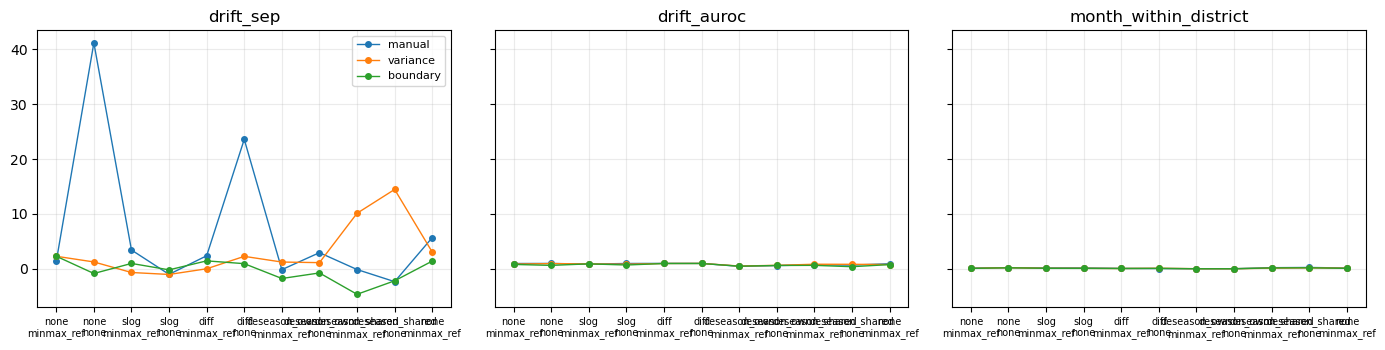

In [ ]:
A = RESULTS[RESULTS["window_size"] == PREP_BASE["window_size"]]
for metric in ("drift_sep", "month_within_district", "sil_district"):
    print(f"-- {metric}")
    display(A.pivot_table(index=["transform", "scaling"], columns="strategy",
                          values=metric).round(3))

fig, ax = plt.subplots(1, 3, figsize=(14, 3.6), sharey=True)
for i, metric in enumerate(("drift_sep", "drift_auroc", "month_within_district")):
    for s in STRATEGIES:
        g = A[A["strategy"] == s].set_index(["transform", "scaling"])[metric]
        ax[i].plot(range(len(g)), g.to_numpy(), marker="o", ms=4, lw=1, label=s)
    ax[i].set_xticks(range(len(g)))
    ax[i].set_xticklabels([f"{a}\n{b}" for a, b in g.index], fontsize=7, rotation=0)
    ax[i].set_title(metric); ax[i].grid(alpha=.25)
ax[0].legend(fontsize=8); fig.tight_layout(); plt.show()

## 11. Across worlds

Same grid, reduced to the fixed-geometry block, run on every usable baseline world.
`run_world` is now a thin loop over `run_cell` -- world switching and disk caching both happen
inside it, so re-running this after an interrupted sweep only trains the missing cells.

In [22]:
def world_audit(world_rows) -> pd.DataFrame:
    """Load each world once and report the params that break cells when they are None.

    Cheap insurance: a world whose manifest is missing `resolution_h` / `n_months`
    used to fail all 30 cells identically, which reads like a code bug rather than a
    data one.
    """
    rows = []
    for _, w in world_rows.iterrows():
        rec = {"tag": w.get("tag"), "sim_hash": w["sim_hash"][:8]}
        try:
            art = P.load_world(w["dir"])
            raw = art["params"].get("time", {}) or {}
            t = world_time(art)
            fl = world_fl(art)
            sched = (pathlib.Path(w["dir"]) / "clone" / "data" / "03_primary"
                     / "gt_drift_schedule.csv")
            rec.update(raw_none=[k for k in ("resolution_h", "days_per_month", "n_months")
                                 if raw.get(k) is None] or "",
                       resolution_h=t["resolution_h"], n_months=t["n_months"],
                       rounds=fl["training"]["rounds"],
                       schedule=sched.exists(),
                       drift_start=drift_start(w["dir"], t["n_months"]),
                       drift_district=w.get("drift_district"),
                       consumption_map=w.get("consumption_map"), ok=True)
        except Exception as exc:
            rec.update(ok=False, error=f"{type(exc).__name__}: {exc}")
        rows.append(rec)
    return pd.DataFrame(rows)


GRID_MULTI = [g for g in GRID if g["prep"] is PREP_BASE]      # drop the geometry block
WORLDS_TO_RUN = usable["dir"].tolist()

AUDIT = world_audit(usable[usable["dir"].isin(WORLDS_TO_RUN)])
display(AUDIT)
bad = AUDIT[~AUDIT["ok"]] if "ok" in AUDIT else AUDIT.iloc[:0]
if len(bad):
    print(f"{len(bad)} world(s) will be skipped -- see the error column")

,tag,sim_hash,raw_none,resolution_h,n_months,rounds,schedule,drift_start,drift_district,consumption_map,ok
0,Clr__LR_LI_LI_LR_LI__baseline,05f3f6ee,,1,30,15,True,4,District_C,LR_LI_LI_LR_LI,True
1,Dli__LI_LR_LI_LR_LI__baseline,1cc4d212,,1,30,15,True,4,District_D,LI_LR_LI_LR_LI,True
2,Bli__LI_LR_LI_LR_LI__baseline,5c200145,,1,30,15,True,4,District_B,LI_LR_LI_LR_LI,True
3,Ali__LR_LI_LI_LR_LI__baseline,5c7a82bc,,1,30,15,True,4,District_A,LR_LI_LI_LR_LI,True
4,Blr__LR_LI_LI_LR_LI__baseline,5e1522fb,,1,30,15,True,4,District_B,LR_LI_LI_LR_LI,True
5,Elr__LI_LR_LI_LR_LI__baseline,5ef2447c,,1,30,15,True,4,District_E,LI_LR_LI_LR_LI,True
6,Blr__LI_LI_LR_LR_LR__baseline,60febc6a,,1,30,15,True,4,District_B,LI_LI_LR_LR_LR,True
7,Alr__LI_LI_LR_LR_LR__baseline,68c92afc,,1,30,15,True,4,District_A,LI_LI_LR_LR_LR,True
8,Dli__LR_LI_LI_LR_LI__baseline,a1533ae8,,1,30,15,True,4,District_D,LR_LI_LI_LR_LI,True
9,Clr__LI_LR_LI_LR_LI__baseline,b66afa54,,1,30,15,True,4,District_C,LI_LR_LI_LR_LI,True


In [23]:
def run_world(world_row, grid, cap=CAP, rounds=ROUNDS) -> pd.DataFrame:
    """All cells of one world. A world that cannot be loaded fails ONCE, not per cell."""
    try:
        set_world_context(world_row)                     # pre-flight, so errors report once
    except Exception as exc:
        print(f"    world unusable: {type(exc).__name__}: {exc}")
        return pd.DataFrame()
    rows = []
    for g in grid:
        try:
            rows.append(run_cell(world_row, **g, rounds=rounds, cap=cap))
        except Exception as exc:
            print(f"    {g['strategy']}/{g['transform']}/{g['scaling']} FAILED "
                  f"{type(exc).__name__}: {exc}")
    return pd.DataFrame(rows)


all_rows = []
for wd in WORLDS_TO_RUN:
    w = usable[usable["dir"] == wd].iloc[0]
    t0 = time.time()
    print(f"=== {w['tag']} ({w['sim_hash'][:8]}) ===")
    df = run_world(w, GRID_MULTI)
    if len(df):
        all_rows.append(df)
    else:
        print("    no cells succeeded -- skipped")
    print(f"    {time.time() - t0:.0f}s")

MULTI = pd.concat(all_rows, ignore_index=True) if all_rows else pd.DataFrame()
if len(MULTI) and "world_id" in MULTI.columns:
    meta = [c for c in ("sim_hash", "variant", "sim_seed", "consumption_map", "beta",
                        "n_months") if c in usable.columns]
    MULTI = MULTI.merge(usable[meta].rename(columns={"sim_hash": "world_id"}),
                        on="world_id", how="left")
    print(f"{MULTI['world_id'].nunique()} worlds x {len(GRID_MULTI)} cells = {len(MULTI)} rows "
          f"(per-cell tables under {SANDBOX}/<world_id>/<cell_id>/)")
else:
    print("MULTI is empty -- no world produced a scored cell; read the errors above")

=== Clr__LR_LI_LI_LR_LI__baseline (05f3f6ee) ===
    1431s
=== Dli__LI_LR_LI_LR_LI__baseline (1cc4d212) ===
    1487s
=== Bli__LI_LR_LI_LR_LI__baseline (5c200145) ===
    1471s
=== Ali__LR_LI_LI_LR_LI__baseline (5c7a82bc) ===
    1460s
=== Blr__LR_LI_LI_LR_LI__baseline (5e1522fb) ===
    1472s
=== Elr__LI_LR_LI_LR_LI__baseline (5ef2447c) ===
    1484s
=== Blr__LI_LI_LR_LR_LR__baseline (60febc6a) ===
    1485s
=== Alr__LI_LI_LR_LR_LR__baseline (68c92afc) ===
    1491s
=== Dli__LR_LI_LI_LR_LI__baseline (a1533ae8) ===
    1481s
=== Clr__LI_LR_LI_LR_LI__baseline (b66afa54) ===
    1457s
=== Elr__LR_LI_LI_LR_LI__baseline (c741d84a) ===
    1467s
=== Dli__LI_LI_LR_LR_LR__baseline (d12ead41) ===
    1439s
=== Alr__LI_LR_LI_LR_LI__baseline (d5ade6af) ===
    1471s
=== Eli__LI_LI_LR_LR_LR__baseline (d90dd40e) ===
    1485s
=== Cli__LI_LI_LR_LR_LR__baseline (ddf8b982) ===
    1469s
=== Dli__LI_LR_LR_LR_LI__baseline (e0f8c48c) ===
    3s
16 worlds x 30 cells = 480 rows (per-cell tables under C:\U

In [24]:
REF = {"strategy": "manual", "transform": "none", "scaling": "minmax_ref"}
METRICS = ("drift_auroc", "drift_rank", "drift_gap", "drift_sep", "month_within_district")

# NOTE: always MULTI["transform"], never MULTI.transform -- the latter is a DataFrame
# method, so `MULTI.transform == "none"` is False and silently empties the mask.
mask = np.ones(len(MULTI), bool)
for k, v in REF.items():
    mask &= (MULTI[k] == v).to_numpy()
ref = MULTI[mask].drop_duplicates("world_id").set_index("world_id")
print(f"MULTI: {len(MULTI)} rows, {MULTI['world_id'].nunique()} worlds | "
      f"reference cell: {len(ref)} world(s)")

delta = []
for (s, t, k), g in MULTI.groupby(["strategy", "transform", "scaling"]):
    g = g.drop_duplicates("world_id").set_index("world_id")
    common = g.index.intersection(ref.index)
    if not len(common):
        continue
    for metric in (m for m in METRICS if m in g.columns and m in ref.columns):
        d = (pd.to_numeric(g.loc[common, metric], errors="coerce")
             - pd.to_numeric(ref.loc[common, metric], errors="coerce")).dropna()
        if not len(d):
            continue
        n = len(d)
        se = float(d.std(ddof=1) / np.sqrt(n)) if n > 1 else np.nan
        delta.append(dict(strategy=s, transform=t, scaling=k, metric=metric, n=n,
                          mean_delta=float(d.mean()), median_delta=float(d.median()),
                          wins=int((d > 0).sum()), se=se,
                          t=(float(d.mean()) / se if se and se > 0 else np.nan)))

DELTA = pd.DataFrame(delta, columns=["strategy", "transform", "scaling", "metric", "n",
                                     "mean_delta", "median_delta", "wins", "se", "t"])

# scale-free metrics first; drift_sep is an annotation, not a ranking key
for metric in ("drift_auroc", "month_within_district", "drift_gap", "drift_sep"):
    sub = DELTA[DELTA["metric"] == metric]
    if len(sub):
        print(f"\n== {metric}: paired delta vs {REF['strategy']}/{REF['transform']}/"
              f"{REF['scaling']} ==")
        display(sub.sort_values("median_delta", ascending=False)
                [["strategy", "transform", "scaling", "n", "wins", "median_delta",
                  "mean_delta", "t"]].round(3))
print(f"\nn = {DELTA['n'].max()} worlds -> read `wins` out of `n`; |t| needs n >= 6 to mean much.")

# raw pivots, also by bracket access
print("\n== drift_auroc (scale-free) ==")
display(MULTI.pivot_table(index=["transform", "scaling"], columns="strategy",
                          values="drift_auroc", aggfunc=["mean", "std"]).round(3))
print("== drift_rank (1 = the drifted district ranked first) ==")
display(MULTI.pivot_table(index=["transform", "scaling"], columns="strategy",
                          values="drift_rank", aggfunc="mean").round(2))

MULTI: 480 rows, 16 worlds | reference cell: 16 world(s)

== drift_auroc: paired delta vs manual/none/minmax_ref ==


,strategy,transform,scaling,n,wins,median_delta,mean_delta,t
80,manual,none,minmax_ref,16,0,0.000,0.000,NaN
140,variance,slog,minmax_ref,16,1,0.000,-0.010,-1.959
135,variance,none,none,16,1,0.000,-0.026,-1.290
130,variance,none,minmax_ref,16,1,0.000,-0.025,-2.140
25,boundary,diff,none,16,1,0.000,-0.013,-2.494
30,boundary,none,minmax_ref,16,1,0.000,-0.044,-2.227
125,variance,diff,none,16,1,0.000,-0.014,-1.696
40,boundary,slog,minmax_ref,16,1,0.000,-0.024,-2.119
95,manual,slog,none,16,2,0.000,-0.003,-1.027
90,manual,slog,minmax_ref,16,1,0.000,-0.011,-1.415



== month_within_district: paired delta vs manual/none/minmax_ref ==


,strategy,transform,scaling,n,wins,median_delta,mean_delta,t
69,manual,deseason_shared,none,16,15,0.115,0.101,9.377
64,manual,deseason_shared,minmax_ref,16,15,0.056,0.047,5.672
89,manual,none,none,16,14,0.022,0.020,5.413
99,manual,slog,none,16,14,0.013,0.012,4.727
19,boundary,deseason_shared,none,16,8,0.010,-0.002,-0.135
139,variance,none,none,16,11,0.006,0.015,1.676
39,boundary,none,none,16,8,0.001,0.006,0.874
84,manual,none,minmax_ref,16,0,0.000,0.000,NaN
94,manual,slog,minmax_ref,16,6,-0.006,-0.002,-0.540
119,variance,deseason_shared,none,16,6,-0.009,-0.022,-1.612



== drift_gap: paired delta vs manual/none/minmax_ref ==


...

,strategy,transform,scaling,n,wins,median_delta,mean_delta,t
98,manual,slog,none,16,9,70.740,1016.847,1.307
73,manual,diff,minmax_ref,16,13,23.590,879.417,2.190
93,manual,slog,minmax_ref,16,11,4.446,83.253,2.007
48,boundary,slog,none,16,8,3.608,94.408,1.103
123,variance,diff,minmax_ref,16,8,0.885,91.014,0.854
23,boundary,diff,minmax_ref,16,10,0.874,102.358,0.795
88,manual,none,none,16,9,0.292,28.699,0.688
83,manual,none,minmax_ref,16,0,0.000,0.000,NaN
28,boundary,diff,none,16,5,-2.017,-38.141,-1.419
128,variance,diff,none,16,5,-2.319,-43.220,-1.566



n = 16 worlds -> read `wins` out of `n`; |t| needs n >= 6 to mean much.

== drift_auroc (scale-free) ==


mean                      std                
strategy                   boundary manual variance boundary manual variance
transform       scaling                                                     
deseason_own    minmax_ref    0.632  0.710    0.668    0.157  0.183    0.161
                none          0.613  0.659    0.680    0.120  0.126    0.132
deseason_shared minmax_ref    0.755  0.883    0.793    0.168  0.089    0.162
                none          0.697  0.882    0.744    0.167  0.090    0.142
diff            minmax_ref    0.973  0.995    0.967    0.030  0.014    0.061
                none          0.985  0.980    0.984    0.020  0.028    0.033
none            minmax_ref    0.954  0.998    0.973    0.081  0.006    0.049
                none          0.951  0.998    0.972    0.095  0.007    0.081
slog            minmax_ref    0.974  0.988    0.988    0.046  0.034    0.025
                none          0.967  0.995    0.974    0.072  0.012    0.044

== drift_rank (1 = the drifted district ranked first) ==


strategy                    boundary  manual  variance
transform       scaling                               
deseason_own    minmax_ref      2.25    1.81      1.94
                none            2.69    2.81      2.62
deseason_shared minmax_ref      2.44    2.06      2.12
                none            2.50    2.69      2.50
diff            minmax_ref      1.19    1.25      2.12
                none            1.56    2.00      1.56
none            minmax_ref      1.88    1.69      2.00
                none            2.75    1.62      2.69
slog            minmax_ref      1.69    1.56      2.19
                none            1.88    2.12      2.44

## 12. Latent space explorer

Three panels -- `manual / variance / boundary` -- for one preprocessing combination, with a
**round** slider. Every dropdown cascades over what is actually on disk, so any state you can
reach exists; combinations you never trained show an empty panel. Nothing here trains.

Rounds come from `latents_by_round`; cells trained before SS.7a have no snapshots and fall back
to their final `latent_trajectories` (shown as round `final`). The projection is fitted **per
panel over all of that panel's rounds at once**, so movement between frames is real movement and
not a re-fit -- but each panel keeps its own axes, because the three placements are separately
trained models whose latent bases are unrelated. Compare *structure* across panels, never
position.

In [25]:
def project(Z, method, seed=0):
    Zs = StandardScaler().fit_transform(Z)
    if method == "PCA":
        p = PCA(n_components=2, random_state=seed).fit(Zs)
        sub = "  ".join(f"PC{i+1} {v:.1%}" for i, v in enumerate(p.explained_variance_ratio_))
        return p.transform(Zs), sub
    if method == "t-SNE":
        from sklearn.manifold import TSNE
        perp = min(30, max(5, len(Zs) // 4))
        return TSNE(n_components=2, init="pca", random_state=seed, perplexity=perp).fit_transform(Zs), "t-SNE"
    import umap
    return umap.UMAP(n_components=2, random_state=seed).fit_transform(Zs), "UMAP"


try:
    import umap; HAS_UMAP = True
except Exception:
    HAS_UMAP = False

AttributeError: module 'ml_dtypes' has no attribute 'float8_e4m3b11'

In [ ]:
import re

# ---------------------------------------------------------------- inventory
def _parse_cell_id(cid: str) -> dict | None:
    try:
        strategy, transform, scaling, geom = cid.split("__")
        m = re.fullmatch(r"a(\d+)w(\d+)s(\d+)", geom)
        return dict(strategy=strategy, transform=transform, scaling=scaling,
                    interval_agg_h=int(m[1]), window_size=int(m[2]), step_size=int(m[3]))
    except Exception:
        return None


SPEC_COLS = ["interval_agg_h", "window_size", "step_size", "transform", "scaling"]
METRIC_COLS = ["drift_rank", "drift_sep", "month_within_district"]


def build_inventory() -> pd.DataFrame:
    """Every cell on disk. Registry first; falls back to RESULTS/MULTI in memory."""
    frames = []
    reg = load_registry()
    if len(reg):
        rows = []
        for _, r in reg.iterrows():
            spec = _parse_cell_id(r["cell_id"])
            if spec:
                rows.append({**spec, "world_id": r["world_id"], "cell_id": r["cell_id"],
                             **{k: r.get(k) for k in METRIC_COLS}})
        frames.append(pd.DataFrame(rows))
    for name in ("RESULTS", "MULTI"):                 # in-memory, in case runs.csv lags
        df = globals().get(name)
        if isinstance(df, pd.DataFrame) and len(df) and "cell_id" in df.columns:
            keep = ["strategy", "world_id", "cell_id"] + SPEC_COLS + \
                   [c for c in METRIC_COLS if c in df.columns]
            frames.append(df[[c for c in keep if c in df.columns]].copy())
    if not frames:
        return pd.DataFrame(columns=["strategy", "world_id", "cell_id"] + SPEC_COLS)
    inv = pd.concat(frames, ignore_index=True)
    return inv.drop_duplicates(["world_id", "cell_id"], keep="first")


INV = build_inventory()
if not len(INV):
    print(f"nothing saved under {SANDBOX} and no RESULTS in memory -- run SS.8 first")
else:
    print(f"{len(INV)} cells | {INV['world_id'].nunique()} world(s) | geometries: "
          + ", ".join(f"a{a}w{w}s{s}" for a, w, s in
                      INV[["interval_agg_h", "window_size", "step_size"]]
                      .drop_duplicates().itertuples(index=False)))

_TAGS = dict(zip(usable["sim_hash"], usable["tag"]))
WORLD_OPTIONS = [(_TAGS.get(w, w[:12]), w) for w in sorted(INV["world_id"].unique())] \
    if len(INV) else [("(none)", None)]

FINAL_ROUND_KEY = 10**6          # stands in for "final model, no snapshots"
_TBL: dict = {}
_EMB: dict = {}


def _cell_frame(world_id, cell_id):
    """Per-round snapshots if saved, else the final latents tagged FINAL_ROUND_KEY."""
    key = (world_id, cell_id)
    if key not in _TBL:
        c = load_cell(world_id, cell_id)
        if c is None:
            _TBL[key] = None
        else:
            lbr, lt = c.get("latents_by_round"), c.get("latent_trajectories")
            if lbr is not None and len(lbr):
                _TBL[key] = lbr
            elif lt is not None and len(lt):
                _TBL[key] = lt.assign(round=FINAL_ROUND_KEY)
            else:
                _TBL[key] = None
    return _TBL[key]


def _embed(world_id, cell_id, method, n_pts, seed=0):
    """(frame, embedding, subtitle) with ONE projection fitted over all rounds."""
    key = (world_id, cell_id, method, n_pts)
    if key in _EMB:
        return _EMB[key]
    df = _cell_frame(world_id, cell_id)
    if df is None:
        _EMB[key] = None
        return None
    if n_pts:
        per = max(50, int(n_pts) // max(1, df["round"].nunique()))
        rng = np.random.default_rng(seed)
        df = pd.concat([g.iloc[rng.choice(len(g), min(per, len(g)), replace=False)]
                        for _, g in df.groupby("round")], ignore_index=True)
    f = [c for c in df.columns if c.startswith("f") and c[1:].isdigit()]
    E, sub = project(df[f].to_numpy(float), method)
    _EMB[key] = (df.reset_index(drop=True), E, sub)
    return _EMB[key]


def _round_label(r) -> str:
    return "final" if r == FINAL_ROUND_KEY else ("init (-1)" if r == -1 else f"r{int(r)}")


# ---------------------------------------------------------------- controls
_world  = W.Dropdown(options=WORLD_OPTIONS, value=WORLD_OPTIONS[0][1], description="world")
_agg    = W.Dropdown(description="agg h")
_win    = W.Dropdown(description="window")
_step   = W.Dropdown(description="stride")
_trans  = W.Dropdown(description="transform")
_scal   = W.Dropdown(description="scaling")
_method = W.Dropdown(options=["PCA", "t-SNE"] + (["UMAP"] if HAS_UMAP else []),
                     value="PCA", description="method")
_color  = W.Dropdown(options=["district", "month", "hour", "drift status"],
                     value="district", description="color")
_pts    = W.Dropdown(options=[("2k", 2000), ("4k", 4000), ("8k", 8000), ("all", 0)],
                     value=4000, description="points")
_round  = W.SelectionSlider(options=[("final", FINAL_ROUND_KEY)], value=FINAL_ROUND_KEY,
                            description="round", continuous_update=False,
                            layout=W.Layout(width="80%"))
_status, _plot = W.Output(), W.Output()

CTL = dict(zip(SPEC_COLS, (_agg, _win, _step, _trans, _scal)))
PREFERRED = {"transform": "none", "scaling": "minmax_ref"}     # nicer landing state
_lock = {"busy": False}


def _current():
    prep = dict(interval_agg_h=_agg.value, window_size=_win.value, step_size=_step.value)
    if any(v is None for v in list(prep.values()) + [_trans.value, _scal.value]):
        return None
    return _world.value, prep, _trans.value, _scal.value


def _sync_options(*_):
    """Cascade: each dropdown offers only values that exist given the ones above it."""
    if _lock["busy"] or not len(INV):
        return
    _lock["busy"] = True
    sub = INV[INV.world_id == _world.value]
    for col in SPEC_COLS:
        opts = sorted(sub[col].dropna().unique().tolist())
        ctl = CTL[col]
        val = ctl.value if ctl.value in opts else \
            (PREFERRED[col] if PREFERRED.get(col) in opts else (opts[0] if opts else None))
        ctl.options, ctl.value = opts, val
        sub = sub[sub[col] == val]
    _lock["busy"] = False
    _sync_rounds()


def _sync_rounds(*_):
    """Round options = union of rounds available across the three placements."""
    if _lock["busy"]:
        return
    cur = _current()
    if cur is None:
        return
    wid, prep, t, k = cur
    rounds = set()
    for s in STRATEGIES:
        df = _cell_frame(wid, cell_id_for(s, t, k, prep))
        if df is not None:
            rounds |= set(int(r) for r in df["round"].unique())
    opts = [(_round_label(r), r) for r in sorted(rounds)] or [("final", FINAL_ROUND_KEY)]
    _lock["busy"] = True
    keep = _round.value if _round.value in [v for _, v in opts] else opts[-1][1]
    _round.options, _round.value = opts, keep
    _lock["busy"] = False
    _redraw()


def _redraw(*_):
    if _lock["busy"] or not len(INV):
        return
    cur = _current()
    if cur is None:
        return
    wid, prep, t, k = cur
    sub_inv = INV[INV.world_id == wid]

    with _plot:
        _plot.clear_output(wait=True)
        fig, axes = plt.subplots(1, 3, figsize=(16.5, 5.4))
        panels, missing = [], []
        for ax, s in zip(axes, STRATEGIES):
            cid = cell_id_for(s, t, k, prep)
            emb = _embed(wid, cid, _method.value, _pts.value) \
                if (sub_inv.cell_id == cid).any() else None
            ax.grid(alpha=.2)
            if emb is None:
                missing.append(s)
                ax.set_title(s, fontsize=10)
                ax.text(.5, .5, "not saved", ha="center", va="center", fontsize=9,
                        color="grey", transform=ax.transAxes)
                ax.set_xticks([]); ax.set_yticks([])
                continue
            df, E, proj_sub = emb
            m = (df["round"] == _round.value).to_numpy()
            if not m.any():
                missing.append(f"{s}@{_round_label(_round.value)}")
                ax.set_title(s, fontsize=10)
                ax.text(.5, .5, f"no snapshot at\n{_round_label(_round.value)}",
                        ha="center", va="center", fontsize=9, color="grey",
                        transform=ax.transAxes)
                ax.set_xticks([]); ax.set_yticks([])
                continue
            r = sub_inv[sub_inv.cell_id == cid].iloc[0]
            ax.set_title(f"{s}\nrank {r.drift_rank:.0f}  sep {r.drift_sep:+.2f}  "
                         f"mwd {r.month_within_district:.2f}\n{proj_sub}", fontsize=8)
            ax.set_xlim(E[:, 0].min(), E[:, 0].max())      # frame fixed across rounds
            ax.set_ylim(E[:, 1].min(), E[:, 1].max())
            panels.append((ax, df[m], E[m]))

        cb = None
        if _color.value in ("district", "drift status"):
            key = "district" if _color.value == "district" else "drift_status"
            cats = sorted({c for _, d, _ in panels for c in d[key].unique()})
            cmap = plt.get_cmap("tab10")
            col = {c: cmap(i % 10) for i, c in enumerate(cats)}
            for ax, d, E in panels:
                for c in cats:
                    m = (d[key] == c).to_numpy()
                    if m.any():
                        ax.scatter(E[m, 0], E[m, 1], s=7, alpha=.6, color=col[c],
                                   label=c, linewidths=0)
            if panels:
                panels[0][0].legend(fontsize=7, markerscale=2, loc="best")
        elif panels:
            vals = np.concatenate([d[_color.value].to_numpy() for _, d, _ in panels])
            cmap = "twilight" if _color.value == "hour" else "YlOrBr"
            vmin, vmax = (0, 24) if _color.value == "hour" else (vals.min(), vals.max())
            for ax, d, E in panels:
                cb = ax.scatter(E[:, 0], E[:, 1], c=d[_color.value].to_numpy(), s=7,
                                alpha=.7, cmap=cmap, vmin=vmin, vmax=vmax, linewidths=0)
            fig.colorbar(cb, ax=list(axes)).set_label(_color.value)

        fig.suptitle(f"{_TAGS.get(wid, str(wid)[:12])}  ·  {t} · {k} · "
                     f"agg {prep['interval_agg_h']}h · w{prep['window_size']} · "
                     f"s{prep['step_size']}  ·  {_method.value}  ·  "
                     f"{_round_label(_round.value)}", fontsize=10)
        if cb is None:
            fig.tight_layout(rect=[0, 0, 1, .92])
        plt.show()

    with _status:
        _status.clear_output(wait=True)
        print(f"{len(panels)}/3 placements plotted"
              + (f"  |  missing: {', '.join(missing)}" if missing else ""))


_world.observe(_sync_options, names="value")
for col in SPEC_COLS:
    CTL[col].observe(_sync_options, names="value")     # spec change re-cascades + re-rounds
_round.observe(_redraw, names="value")
for ctl in (_method, _color, _pts):
    ctl.observe(_redraw, names="value")

display(W.VBox([W.HBox([_world, _method, _color, _pts]),
                W.HBox([_agg, _win, _step]), W.HBox([_trans, _scal]),
                _round, _status, _plot]))
_sync_options()

492 cells | 16 world(s) | geometries: a3w84s12, a2w24s2, a2w24s6, a3w84s24, a4w48s12


## 13. Client similarity and clustering -- init vs final

The `personalization` question, not the dependence one: **which clients look alike**, and does
that change between commissioning and the drifted end state. The pipeline's helpers do the work
(`_deconfounded_prototypes`, `_drift_signatures`, `_cosine_sim_matrix`, `_cluster`); this section
picks the slices and scores them.

`client_dependence` does not exist for these cells, so the coupling channel is inert and
`S_eff == S_fused` -- the non-dependence view, and what the architecture doc says happens anyway
when no pair clears `coupling_q_threshold`.

**Two phases**, `PHASE_LEN` months each: `init` (first) and `final` (last). `consumption_map`
describes the world at commissioning, so `init` is the only slice where the regime labels are
unambiguous. Deconfounding is per-month, so slicing before or after it is identical.

**Scored on the `dom` channel only.** `S_drift` is built from `delta_first`, which is ~0 in the
first months, so it and any fusion containing it are noise in `init`. `s_drift` and `s_fused` are
still stored per pair for inspection.

Runs off `prototype_history`, which already carries `round` -- **no retraining**, so cells trained
before SS.7a work here too.

In [27]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import adjusted_rand_score

from fedwater.pipelines.personalization.nodes import (
    _cluster, _cosine_sim_matrix, _deconfounded_prototypes, _drift_signatures,
    build_personalization_clusters)

FCOLS = lambda df: [c for c in df.columns if c.startswith("f") and c[1:].isdigit()]
PHASE_LEN = 3
PHASES = ("init", "final")
SD_FLOOR = 1e-3                  # below this a similarity matrix has no structure to cluster

W_DOMAIN = 0.5
_pers = ART["params"].get("personalization", {}) or {}
W_DOMAIN = float(next((v for k, v in _pers.items()
                       if "domain" in k.lower() and isinstance(v, (int, float))), W_DOMAIN))


def world_meta(world_id: str) -> dict:
    row = usable[usable["sim_hash"] == world_id]
    if not len(row):
        return {}
    w = row.iloc[0]
    return dict(tag=w["tag"], regimes=_regimes_of(w), drift_client=w.get("drift_district"),
                drift_start=drift_start(w["dir"], w.get("n_months") or TIME["n_months"]))


WMETA = {wid: world_meta(wid) for wid in INV["world_id"].unique()}


def phase_months(months, n=PHASE_LEN) -> dict:
    ms = sorted(int(m) for m in pd.unique(pd.Series(months)))
    return {"init": ms[:n], "final": ms[-n:]}


# ---------------------------------------------------------------- similarity
def _stacks_to_matrix(stacks: dict):
    ks = sorted(stacks)
    A = [np.atleast_2d(np.asarray(stacks[k], float)) for k in ks]
    n = min(len(a) for a in A)
    return ks, np.vstack([a[:n].ravel() for a in A])


def _cos(M: np.ndarray) -> np.ndarray:
    try:
        S = np.asarray(_cosine_sim_matrix(M), float)
        if S.shape == (len(M), len(M)):
            return S
    except Exception:
        pass
    nrm = np.linalg.norm(M, axis=1, keepdims=True)
    N = M / np.where(nrm > 0, nrm, 1.0)
    return N @ N.T


def _as_stacks(obj, value_col=None) -> dict:
    if isinstance(obj, dict):
        return {k: np.asarray(v, float) for k, v in obj.items()}
    df = pd.DataFrame(obj)
    ccol = next(c for c in df.columns if c.lower() in ("client", "district"))
    cols = FCOLS(df) or [value_col or df.columns[-1]]
    return {c: g.sort_values([x for x in ("month",) if x in g.columns] or cols)[cols]
            .to_numpy(float) for c, g in df.groupby(ccol)}


def similarity_channels(ph: pd.DataFrame, ds: pd.DataFrame, months=None):
    """(clients, S_domain, S_drift)."""
    if months is not None:
        ph, ds = ph[ph["month"].isin(list(months))], ds[ds["month"].isin(list(months))]
    ks, M = _stacks_to_matrix(_as_stacks(_deconfounded_prototypes(ph)))
    S_dom = _cos(M)
    try:
        kd, D = _stacks_to_matrix(_as_stacks(_drift_signatures(ds), "delta_first"))
        S_dri = _cos(D) if kd == ks else None
    except Exception:
        S_dri = None
    if S_dri is None:
        piv = ds.pivot_table(index="client", columns="month", values="delta_first").reindex(ks)
        V = piv.to_numpy(float)
        S_dri = _cos(np.nan_to_num(V - np.nanmean(V, axis=0, keepdims=True)))
    return ks, S_dom, S_dri


def cluster_labels(S: np.ndarray, n_hint=None) -> np.ndarray:
    for args in ((S,), (S, {})):
        try:
            lab = np.asarray(_cluster(*args)).ravel()
            if len(lab) == len(S):
                return lab
        except Exception:
            continue
    D = np.clip(1.0 - S, 0, None); np.fill_diagonal(D, 0.0)
    return AgglomerativeClustering(n_clusters=max(2, min(n_hint or 2, len(S) - 1)),
                                   metric="precomputed", linkage="average").fit_predict(D)


def _gap(S: np.ndarray, ks, mapping: dict) -> float:
    """within- minus between-regime mean similarity. The continuous primary metric."""
    lab = np.array([mapping.get(k, "?") for k in ks])
    eye = np.eye(len(ks), dtype=bool)
    same, diff = (lab[:, None] == lab[None, :]) & ~eye, (lab[:, None] != lab[None, :])
    if not same.any() or not diff.any():
        return np.nan
    return float(np.nanmean(S[same]) - np.nanmean(S[diff]))


def similarity_scores(ks, S, regimes: dict, drift_client=None) -> dict:
    """regime_gap vs its own shuffle null (primary), ARI (secondary), degeneracy flag."""
    eye = np.eye(len(ks), dtype=bool)
    off = S[~eye]
    out = {"sd_offdiag": float(np.nanstd(off)),
           "degenerate": bool(np.nanstd(off) < SD_FLOOR)}
    if regimes:
        gap, p, nullm, n = _shuffle_null(lambda mp: _gap(S, ks, mp), ks, regimes)
        out.update(regime_gap=gap, regime_gap_null=nullm,
                   regime_gap_lift=(gap - nullm if np.isfinite(gap) and np.isfinite(nullm)
                                    else np.nan),
                   regime_gap_p=p, n_assign=n)
        lab = cluster_labels(S, len(set(regimes.values())))
        out["ari_regime"] = float(adjusted_rand_score(
            [regimes.get(k, "?") for k in ks], lab))            # secondary: quantized
        out["n_clusters"] = int(len(set(lab)))
    if drift_client in ks:
        i = ks.index(drift_client)
        m = ~eye
        rest = m.copy(); rest[i, :] = rest[:, i] = False
        out["drift_isolation"] = float(np.nanmean(S[i][m[i]]) - np.nanmean(S[rest]))
    return out

In [28]:
def _fl_for(spec: dict) -> dict:
    fl = copy.deepcopy(FL_BASE)
    fl["preprocessing"].update(spec.get("prep", {}) or {})
    if spec.get("rounds"):
        fl["training"]["rounds"] = spec["rounds"]
    return fl


def _drift_for_round(ph_r: pd.DataFrame, fl: dict) -> pd.DataFrame:
    """delta_first for ONE round; falls back to cosine distance to the first month if
    compute_drift_signals needs the whole history."""
    try:
        ds = compute_drift_signals(ph_r, fl)
        if len(ds) and {"client", "month", "delta_first"} <= set(ds.columns):
            return ds
    except Exception:
        pass
    f, rows = FCOLS(ph_r), []
    for c, g in ph_r.groupby("client"):
        g = g.sort_values("month")
        V = g[f].to_numpy(float); ref = V[0]
        den = np.linalg.norm(V, axis=1) * (np.linalg.norm(ref) or 1.0)
        rows.append(pd.DataFrame({"client": c, "month": g["month"].to_numpy(),
                                  "delta_first": 1.0 - np.divide(
                                      (V * ref).sum(1), np.where(den > 0, den, np.nan))}))
    return pd.concat(rows, ignore_index=True)


def analyse_cell_phases(world_id: str, cell_id: str, save=True):
    """Similarity + clustering at every (round, phase). -> (scores, labels, pairs)."""
    c = load_cell(world_id, cell_id)
    if c is None or c["prototype_history"] is None:
        return None, None, None
    ph_all = c["prototype_history"]
    if "round" not in ph_all.columns:
        return None, None, None

    meta = WMETA.get(world_id, {})
    regimes, dc = meta.get("regimes", {}), meta.get("drift_client")
    fl, spec = _fl_for(c["spec"]), _parse_cell_id(cell_id) or {}
    windows = phase_months(ph_all["month"])
    base = dict(world_id=world_id, cell_id=cell_id, tag=meta.get("tag"), **spec)

    scores, labels, pairs = [], [], []
    for r, ph_r in ph_all.groupby("round"):
        if ph_r["client"].nunique() < 3:
            continue
        try:
            ds_r = _drift_for_round(ph_r, fl)
        except Exception as exc:
            scores.append({**base, "round": int(r), "error": f"{type(exc).__name__}: {exc}"})
            continue
        for phase, months in windows.items():
            try:
                ks, S_dom, S_dri = similarity_channels(ph_r, ds_r, months=months)
                S_fus = W_DOMAIN * S_dom + (1 - W_DOMAIN) * S_dri
                scores.append({**base, "round": int(r), "phase": phase,
                               "n_months": len(months), "n_clients": len(ks),
                               **similarity_scores(ks, S_dom, regimes, dc)})
                labels.append(pd.DataFrame(
                    {"client": ks, "cluster": cluster_labels(
                        S_dom, len(set(regimes.values())) if regimes else 2),
                     "round": int(r), "phase": phase,
                     "world_id": world_id, "cell_id": cell_id}))
                pairs += [dict(**base, round=int(r), phase=phase, client_a=a, client_b=b,
                               s_domain=S_dom[i, j], s_drift=S_dri[i, j], s_fused=S_fus[i, j])
                          for i, a in enumerate(ks) for j, b in enumerate(ks) if i < j]
            except Exception as exc:
                scores.append({**base, "round": int(r), "phase": phase,
                               "error": f"{type(exc).__name__}: {exc}"})

    S_df = pd.DataFrame(scores)
    L_df = pd.concat(labels, ignore_index=True) if labels else None
    P_df = pd.DataFrame(pairs) if pairs else None
    if save and len(S_df):
        save_analysis(world_id, cell_id, clusters_by_phase=L_df, similarity_by_phase=P_df)
    return S_df, L_df, P_df


sc, lab, skipped = [], [], []
for _, r in INV.drop_duplicates(["world_id", "cell_id"]).iterrows():
    S_df, L_df, _ = analyse_cell_phases(r["world_id"], r["cell_id"])
    if S_df is None or not len(S_df):
        skipped.append(r["cell_id"]); continue
    sc.append(S_df)
    if L_df is not None:
        lab.append(L_df)

CLUSTERS_PHASES = pd.concat(sc, ignore_index=True) if sc else pd.DataFrame()
LABELS_PHASES = pd.concat(lab, ignore_index=True) if lab else pd.DataFrame()
if len(CLUSTERS_PHASES):
    CLUSTERS_PHASES.to_csv(SANDBOX / "clustering_by_phase.csv", index=False)
print(f"{len(CLUSTERS_PHASES)} (cell, round, phase) rows | "
      f"{CLUSTERS_PHASES['cell_id'].nunique() if len(CLUSTERS_PHASES) else 0} cells"
      + (f" | skipped {len(skipped)}" if skipped else ""))
if "error" in CLUSTERS_PHASES.columns:
    err = CLUSTERS_PHASES[CLUSTERS_PHASES["error"].notna()]
    if len(err):
        print(f"{len(err)} failed slices"); display(err.head(3))
if "degenerate" in CLUSTERS_PHASES.columns and CLUSTERS_PHASES["degenerate"].any():
    print(f"{int(CLUSTERS_PHASES['degenerate'].sum())} degenerate matrices "
          f"(sd < {SD_FLOOR}) -- their gap and ARI are meaningless")

14760 (cell, round, phase) rows | 42 cells


In [29]:
# ---- sanity check: does the mover's similarity shift stand out, init -> final? -------
# Denominator-free on purpose. The cluster-crossing version of this test had no power:
# most clients "moved" every round because the clustering was re-cut on a near-identical
# matrix, and the few large z-scores came from dividing by a ~zero spread.
def drift_shift_check(channel="s_domain") -> pd.DataFrame:
    rows = []
    for (wid, cid), _ in LABELS_PHASES.groupby(["world_id", "cell_id"]):
        sim = _read_table(SANDBOX / wid / cid / "similarity_by_phase")
        dc = WMETA.get(wid, {}).get("drift_client")
        if sim is None or dc is None or channel not in sim:
            continue
        for r, gr in sim.groupby("round"):
            d = {}
            for phase in PHASES:
                g = gr[gr.phase == phase]
                if not len(g):
                    break
                long = pd.concat([g.rename(columns={"client_a": "c"})[["c", channel]],
                                  g.rename(columns={"client_b": "c"})[["c", channel]]])
                d[phase] = long.groupby("c")[channel].mean()
            if len(d) < 2:
                continue
            common = d["init"].index.intersection(d["final"].index)
            delta = (d["final"][common] - d["init"][common]).abs()
            if dc not in delta.index or len(delta) < 4:
                continue
            runner = float(delta.drop(dc).max())
            rows.append({"world_id": wid, "cell_id": cid, **(_parse_cell_id(cid) or {}),
                         "round": int(r),
                         "drift_rank_frac": float(delta.rank(pct=True)[dc]),
                         "drift_ratio": float(delta[dc] / max(runner, SD_FLOOR)),
                         "phase_shift": float(delta.mean())})
    return pd.DataFrame(rows)


DRIFT_SHIFT = drift_shift_check()
if len(DRIFT_SHIFT):
    f = DRIFT_SHIFT[DRIFT_SHIFT["round"] == DRIFT_SHIFT["round"].max()]
    print("drift_rank_frac: 1.0 = the mover's similarity shifted most of all clients "
          "(chance ~0.5 at n=5)")
    display(f.pivot_table(index=["transform", "scaling"], columns="strategy",
                          values="drift_rank_frac", aggfunc="mean").round(2))
    hit = f[(f.drift_rank_frac >= 1.0) & (f.drift_ratio > 2)]
    print(f"{len(hit)}/{len(f)} cells: mover ranked first AND >2x the runner-up")
    if len(hit):
        display(hit[["strategy", "transform", "scaling", "drift_ratio"]].round(2))
else:
    print("no similarity_by_phase tables -- run the cell above first")

drift_rank_frac: 1.0 = the mover's similarity shifted most of all clients (chance ~0.5 at n=5)


strategy                    boundary  manual  variance
transform       scaling                               
deseason_own    minmax_ref      0.69    0.57      0.84
                none            0.68    0.46      0.55
deseason_shared minmax_ref      0.52    0.72      0.68
                none            0.65    0.65      0.56
diff            minmax_ref      0.68    0.56      0.57
                none            0.56    0.60      0.54
none            minmax_ref      0.55    0.56      0.55
                none            0.68    0.71      0.65
slog            minmax_ref      0.54    0.69      0.66
                none            0.50    0.66      0.60

15/492 cells: mover ranked first AND >2x the runner-up


,strategy,transform,scaling,drift_ratio
104,boundary,none,minmax_ref,2.95
974,boundary,diff,minmax_ref,2.43
2549,manual,slog,none,2.74
3089,variance,diff,none,2.13
3284,boundary,slog,minmax_ref,2.51
3434,manual,slog,minmax_ref,2.18
3584,variance,slog,minmax_ref,2.23
4934,variance,slog,minmax_ref,2.07
5444,boundary,deseason_shared,minmax_ref,2.50
5594,manual,deseason_shared,minmax_ref,2.03


## 14. Clustering figures

== regime_gap_lift at round 14 (primary metric; >0 beats the shuffle null) ==


phase                         final                     init                
strategy                   boundary manual variance boundary manual variance
transform       scaling                                                     
deseason_own    minmax_ref   -0.060 -0.101   -0.016   -0.016 -0.133   -0.027
                none          0.014  0.019    0.023    0.010 -0.021   -0.031
deseason_shared minmax_ref   -0.036 -0.026   -0.145   -0.021 -0.010   -0.146
                none          0.082 -0.068    0.031    0.083 -0.069    0.027
diff            minmax_ref    0.101 -0.005    0.039    0.206  0.058    0.071
                none         -0.047  0.077    0.068    0.001  0.161    0.183
none            minmax_ref   -0.013 -0.088    0.004   -0.061 -0.007   -0.021
                none         -0.013 -0.030    0.036    0.037 -0.036    0.001
slog            minmax_ref   -0.026 -0.149    0.024    0.102 -0.062   -0.134
                none          0.127 -0.041    0.064    0.154 -0.045   -0.033

== ARI, same slice (secondary -- quantized, shown for comparison only) ==


phase                       final  init
transform       scaling                
deseason_own    minmax_ref  -0.11 -0.08
                none         0.02 -0.05
deseason_shared minmax_ref  -0.07 -0.08
                none        -0.02 -0.02
diff            minmax_ref   0.02  0.07
                none         0.11  0.16
none            minmax_ref  -0.01 -0.00
                none        -0.02 -0.08
slog            minmax_ref  -0.07 -0.03
                none         0.04  0.02

== does federation build the structure? init phase, round 0 -> 14 ==


final  first   gain
strategy transform       scaling                        
boundary diff            minmax_ref  0.206  0.213 -0.007
variance diff            none        0.183  0.271 -0.088
manual   diff            none        0.161  0.141  0.019
boundary slog            none        0.154  0.067  0.087
                         minmax_ref  0.102  0.242 -0.140
         deseason_shared none        0.083 -0.181  0.265
variance diff            minmax_ref  0.071  0.150 -0.079
manual   diff            minmax_ref  0.058  0.049  0.009
boundary none            none        0.037 -0.189  0.226
variance deseason_shared none        0.027  0.131 -0.104

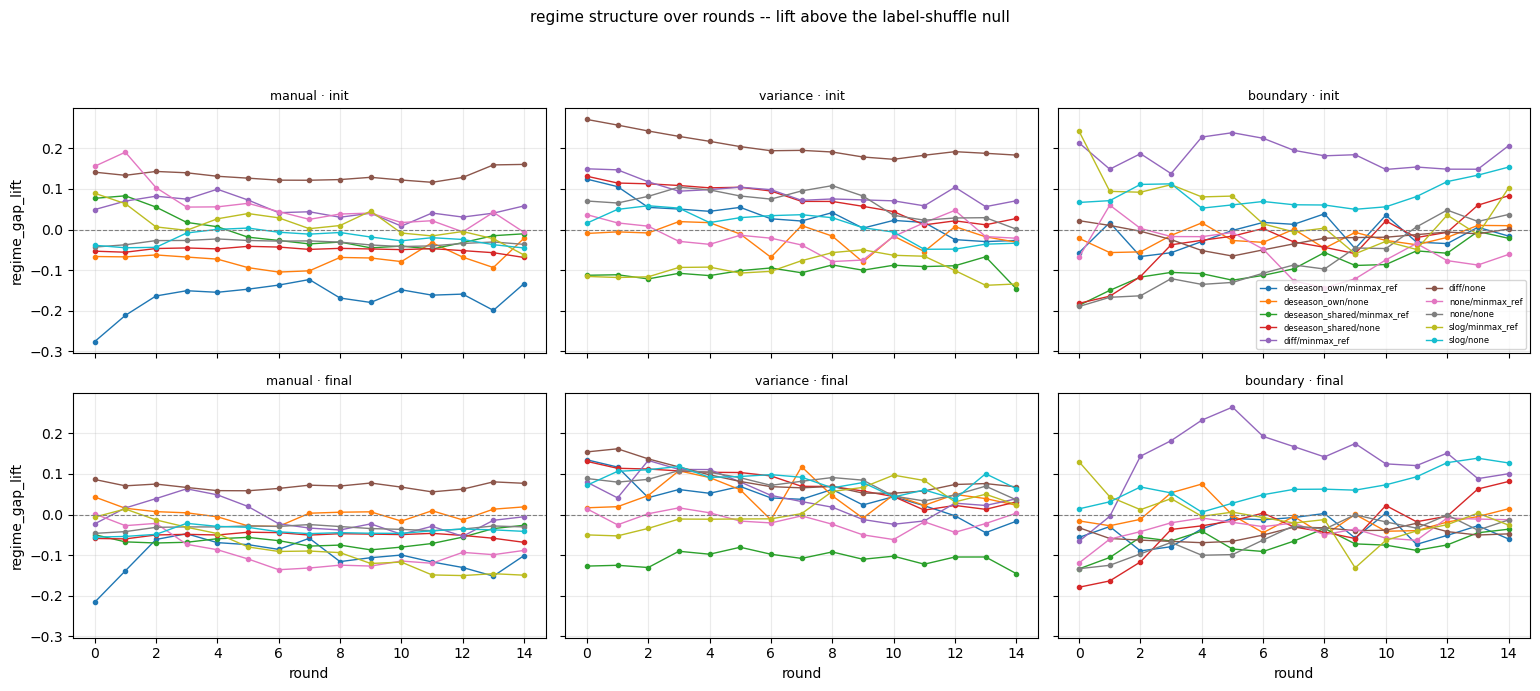

In [30]:
CP = CLUSTERS_PHASES
CP = CP[CP["error"].isna()] if "error" in CP.columns else CP
CP = CP[(CP["window_size"] == PREP_BASE["window_size"]) & ~CP.get("degenerate", False)]
FINAL_R = CP["round"].max()

print(f"== regime_gap_lift at round {FINAL_R} (primary metric; >0 beats the shuffle null) ==")
display(CP[CP["round"] == FINAL_R]
        .pivot_table(index=["transform", "scaling"], columns=["phase", "strategy"],
                     values="regime_gap_lift", aggfunc="mean").round(3))

print("== ARI, same slice (secondary -- quantized, shown for comparison only) ==")
display(CP[CP["round"] == FINAL_R]
        .pivot_table(index=["transform", "scaling"], columns=["phase"],
                     values="ari_regime", aggfunc="mean").round(2))

print(f"== does federation build the structure? init phase, round {CP['round'].min()} "
      f"-> {FINAL_R} ==")
keys = ["strategy", "transform", "scaling"]
ini = CP[(CP.phase == "init") & (CP["round"] == CP["round"].min())].groupby(keys)
fin = CP[(CP.phase == "init") & (CP["round"] == FINAL_R)].groupby(keys)
cmp = (fin["regime_gap_lift"].mean().rename("final")
       .to_frame().join(ini["regime_gap_lift"].mean().rename("first")))
cmp["gain"] = cmp["final"] - cmp["first"]
display(cmp.sort_values("final", ascending=False).round(3).head(10))

# regime_gap_lift over rounds, faceted by PLACEMENT (never averaged over it)
fig, axes = plt.subplots(len(PHASES), len(STRATEGIES), figsize=(15.5, 7), sharey=True,
                         sharex=True, squeeze=False)
for i, phase in enumerate(PHASES):
    for j, s in enumerate(STRATEGIES):
        ax = axes[i][j]
        for (t, k), g in CP[(CP.phase == phase) & (CP.strategy == s)] \
                .groupby(["transform", "scaling"]):
            v = g.groupby("round")["regime_gap_lift"].mean()
            ax.plot(v.index, v.to_numpy(), marker="o", ms=3, lw=1, label=f"{t}/{k}")
        ax.axhline(0, ls="--", c="grey", lw=.8)
        ax.set_title(f"{s} · {phase}", fontsize=9); ax.grid(alpha=.25)
        if i == len(PHASES) - 1:
            ax.set_xlabel("round")
axes[0][0].set_ylabel("regime_gap_lift"); axes[1][0].set_ylabel("regime_gap_lift")
axes[0][-1].legend(fontsize=6, ncol=2, loc="best")
fig.suptitle("regime structure over rounds -- lift above the label-shuffle null", fontsize=11)
fig.tight_layout(rect=[0, 0, 1, .93]); plt.show()

In [31]:
def validate_node(world_id, cell_id) -> str:
    """Run the real personalization node with an inert dependence channel, to confirm our
    hand-composed S_fused matches what the pipeline would build."""
    c = load_cell(world_id, cell_id)
    ph, ds = c["prototype_history"], c["drift_signals"]
    clients = sorted(ph["client"].unique())
    empty_dep = pd.DataFrame([
        dict(district_a=a, district_b=b, level="T", method="rv", statistic=0.0,
             p_value=1.0, q_value=1.0)
        for i, a in enumerate(clients) for b in clients[i + 1:]])
    last = "no attempt"
    for params in (ART["params"].get("personalization", {}), {}, None):
        try:
            res = build_personalization_clusters(ph, ds, empty_dep, params) if params is not None \
                else build_personalization_clusters(ph, ds, empty_dep)
            sm = next(x for x in (res if isinstance(res, tuple) else (res,))
                      if isinstance(x, pd.DataFrame)
                      and any("s_" in col or "sim" in col.lower() for col in x.columns))
            return f"node ran; similarity frame {sm.shape}, cols {list(sm.columns)[:6]}"
        except Exception as exc:
            last = f"{type(exc).__name__}: {exc}"
    return f"node not callable here ({last}) -- using the helper composition in SS.14"


if len(INV):
    print(validate_node(INV.iloc[0]["world_id"], INV.iloc[0]["cell_id"]))

node not callable here (TypeError: build_personalization_clusters() missing 2 required positional arguments: 'fl' and 'seed') -- using the helper composition in SS.14


## 15. Correcting the clustering for hydraulic coupling (Jacobian)

Everything above reads sensors, and a sensor in district A responds to district B's demand
through shared pipes. So two districts can look alike in `S_domain` for a purely structural
reason -- **their sensors see the same water** -- with no similarity in consumption behaviour.
That is a confound for the clustering question specifically, and `jval_engine` already quantifies
it: the district Jacobian `Jd` (sensors x districts) is the sensitivity of each placed meter to
each district's demand.

Two ways to use it, cheapest first:

| route | operation | cost |
|---|---|---|
| **partial out** (this section) | regress the pair similarities on a Jacobian coupling covariate, cluster on the residual | no retraining |
| **unmix the input** | feed `d_hat = Jd^+ y` per district instead of raw sensors, then retrain | one grid re-run, `F = 1` channel |

Two covariates, both from `Jd`:

- `footprint` -- cosine between columns of `Jd`. High means two districts move the placed sensors
  in nearly the same direction, so any sensor-derived representation conflates them.
- `leak` -- row-normalised mass of `Jd^+` landing on *another* district's meters: how much of
  district A's recoverable signal actually arrives through B's sensors. Symmetrised.

**Caveat worth stating before reading the result.** This removes coupling that is a function of
topology and placement. If regime happens to correlate with position in the network, partialling
it out removes real signal too -- so the honest read is the *pair* (uncorrected, corrected), not
the corrected number alone.

In [32]:
import notebooks.SensorPlacement.jval_engine as J

In [33]:
try:
    import notebooks.SensorPlacement.jval_engine as J
    HAS_JVAL = True
except Exception as exc:
    HAS_JVAL = False
    print(f"jval_engine not importable ({type(exc).__name__}) -- put jval_engine.py on the "
          f"path (notebooks/) to enable this section")

JAC_ARM = "J_pre"          # probe at the pre-window operating point
JAC_RCOND = 1e-3
_JAC_CACHE: dict = {}


def jacobian_for(world_row, strategy: str, arm=JAC_ARM):
    """(Jd, sensors, art) for one (world, placement). Cached -- each call runs EPANET sweeps.

    Sensor names are the bare pipe ids the Jacobian uses; client channels prefix them `q_`.
    """
    key = (world_row["sim_hash"], strategy, arm)
    if key in _JAC_CACHE:
        return _JAC_CACHE[key]
    if not HAS_JVAL:
        return None, None, None
    art = P.load_world(world_row["dir"])
    dem = J._load(world_row["dir"], "demand")
    flows = art["flows"]
    n = min(len(dem), len(flows))
    masks = J.window_masks(J.month_vector(art, dem, n))
    pl = J.placements(art, names=(strategy,), seed=SEED).get(strategy)
    if pl is None:
        return None, None, None
    sens = [e for e in J.flatten(pl) if e in flows.columns]
    if len(sens) < len(sorted(art["districts"]["districts"])):
        print(f"  {strategy}: {len(sens)} sensors for "
              f"{len(art['districts']['districts'])} districts -- underdetermined, skipped")
        return None, None, None
    Jds, _ = J.jd_arms(art, art["districts"], sens, dem.iloc[:n], masks, arms=(arm,),
                       seed=SEED,
                       anchor_scale=float(world_row.get("anchor_scale", 1.0) or 1.0))
    out = (Jds[arm], sens, art)
    _JAC_CACHE[key] = out
    return out


def coupling_matrices(Jd: pd.DataFrame, placement: dict) -> dict:
    """{name: (district x district) coupling}, diagonal zeroed."""
    ds = list(Jd.columns)
    A = Jd.to_numpy(float)
    nrm = np.linalg.norm(A, axis=0, keepdims=True)
    N = A / np.where(nrm > 0, nrm, 1.0)
    foot = pd.DataFrame(N.T @ N, index=ds, columns=ds)          # footprint collinearity

    Ainv = np.abs(np.linalg.pinv(A, rcond=JAC_RCOND))           # districts x sensors
    own = {d: [s for s in placement.get(d, []) if s in Jd.index] for d in ds}
    pos = {s: i for i, s in enumerate(Jd.index)}
    L = np.zeros((len(ds), len(ds)))
    for i, a in enumerate(ds):
        row = Ainv[i]
        tot = row.sum() or 1.0
        for j, b in enumerate(ds):
            L[i, j] = sum(row[pos[s]] for s in own[b] if s in pos) / tot
    leak = pd.DataFrame((L + L.T) / 2, index=ds, columns=ds)     # symmetrised

    for M in (foot, leak):
        np.fill_diagonal(M.values, 0.0)
    return {"footprint": foot, "leak": leak}


COUPLING = {}
if HAS_JVAL:
    for s in STRATEGIES:
        try:
            Jd, sens, art_s = jacobian_for(WORLD, s)
            if Jd is None:
                continue
            pl = J.placements(art_s, names=(s,), seed=SEED)[s]
            COUPLING[s] = coupling_matrices(Jd, pl)
            print(f"{s}: Jd {Jd.shape}  cond {np.linalg.cond(Jd.to_numpy()):.1f}  "
                  f"mean footprint {COUPLING[s]['footprint'].to_numpy().sum() / (len(Jd.columns) * (len(Jd.columns) - 1)):.3f}")
        except Exception as exc:
            print(f"{s}: {type(exc).__name__}: {exc}")
    if COUPLING:
        display(COUPLING[STRATEGIES[0]]["leak"].round(3))

manual: Jd (15, 5)  cond 10.5  mean footprint 0.280
variance: Jd (15, 5)  cond 7.2  mean footprint 0.303
boundary: Jd (15, 5)  cond 13.4  mean footprint 0.404


,District_A,District_B,District_C,District_D,District_E
District_A,0.0,0.000,0.000,0.000,0.000
District_B,0.0,0.000,0.278,0.045,0.027
District_C,0.0,0.278,0.000,0.213,0.162
District_D,0.0,0.045,0.213,0.000,0.374
District_E,0.0,0.027,0.162,0.374,0.000


In [34]:
COVARIATE = "leak"          # "leak" | "footprint"


def _partial_out(S: pd.DataFrame | np.ndarray, ks, Cmat: pd.DataFrame):
    """Residualise the off-diagonal similarities on the coupling covariate.

    s_ij = a + b*c_ij + e_ij ; the corrected matrix holds e_ij (+ the mean, so the
    scale stays comparable). Diagonal is left at 1.
    """
    S = np.asarray(S, float)
    idx = [(i, j) for i in range(len(ks)) for j in range(i + 1, len(ks))]
    s = np.array([S[i, j] for i, j in idx])
    c = np.array([float(Cmat.loc[ks[i], ks[j]]) for i, j in idx])
    ok = np.isfinite(s) & np.isfinite(c)
    if ok.sum() < 4 or np.std(c[ok]) < 1e-12:
        return S.copy(), np.nan
    b, a = np.polyfit(c[ok], s[ok], 1)
    r = s - (a + b * c)
    out = np.eye(len(ks))
    for (i, j), v in zip(idx, r + s.mean()):
        out[i, j] = out[j, i] = v
    return out, float(np.corrcoef(s[ok], c[ok])[0, 1])


def correct_clustering(covariate=COVARIATE) -> pd.DataFrame:
    """Re-score every saved (cell, round, phase) with coupling partialled out."""
    rows = []
    for (wid, cid), _ in LABELS_PHASES.groupby(["world_id", "cell_id"]):
        sim = _read_table(SANDBOX / wid / cid / "similarity_by_phase")
        spec = _parse_cell_id(cid) or {}
        cpl = COUPLING.get(spec.get("strategy"), {}).get(covariate)
        if sim is None or cpl is None:
            continue
        meta = WMETA.get(wid, {})
        regimes, dc = meta.get("regimes", {}), meta.get("drift_client")
        for (r, phase), g in sim.groupby(["round", "phase"]):
            ks = sorted(set(g["client_a"]) | set(g["client_b"]))
            if len(ks) < 4 or not set(ks) <= set(cpl.index):
                continue
            S = np.eye(len(ks))
            for _, e in g.iterrows():
                i, j = ks.index(e["client_a"]), ks.index(e["client_b"])
                S[i, j] = S[j, i] = e["s_domain"]
            S_c, r_sc = _partial_out(S, ks, cpl)
            raw = similarity_scores(ks, S, regimes, dc)
            cor = similarity_scores(ks, S_c, regimes, dc)
            rows.append({"world_id": wid, "cell_id": cid, "tag": meta.get("tag"), **spec,
                         "round": int(r), "phase": phase, "covariate": covariate,
                         "r_sim_coupling": r_sc,
                         "gap_lift_raw": raw.get("regime_gap_lift"),
                         "gap_lift_corr": cor.get("regime_gap_lift"),
                         "ari_raw": raw.get("ari_regime"), "ari_corr": cor.get("ari_regime"),
                         "drift_iso_raw": raw.get("drift_isolation"),
                         "drift_iso_corr": cor.get("drift_isolation")})
    df = pd.DataFrame(rows)
    if len(df):
        df["gap_lift_delta"] = df["gap_lift_corr"] - df["gap_lift_raw"]
    return df


CORRECTED = correct_clustering() if (HAS_JVAL and COUPLING and len(LABELS_PHASES)) \
    else pd.DataFrame()
if len(CORRECTED):
    CORRECTED.to_csv(SANDBOX / "clustering_coupling_corrected.csv", index=False)
    F = CORRECTED[(CORRECTED["round"] == CORRECTED["round"].max())
                  & (CORRECTED.phase == "init")]
    print(f"covariate = {COVARIATE} | mean corr(similarity, coupling) = "
          f"{F['r_sim_coupling'].mean():+.3f}  "
          f"(near 0 -> the confound was not driving the similarities)")
    print("\n== regime_gap_lift, init phase, before -> after partialling out coupling ==")
    display(F.pivot_table(index=["transform", "scaling"], columns="strategy",
                          values=["gap_lift_raw", "gap_lift_corr"], aggfunc="mean").round(3))
    print("== cells that SURVIVE the correction (lift > 0 both before and after) ==")
    keep_cols = ["strategy", "transform", "scaling", "gap_lift_raw", "gap_lift_corr",
                 "gap_lift_delta", "r_sim_coupling"]
    display(F[(F.gap_lift_raw > 0) & (F.gap_lift_corr > 0)]
            .sort_values("gap_lift_corr", ascending=False)[keep_cols].round(3).head(10))
else:
    print("nothing to correct -- needs jval_engine, SS.13 similarity tables, and a "
          "well-conditioned Jd")

covariate = leak | mean corr(similarity, coupling) = +0.146  (near 0 -> the confound was not driving the similarities)

== regime_gap_lift, init phase, before -> after partialling out coupling ==


gap_lift_corr                 gap_lift_raw                
strategy                        boundary manual variance     boundary manual variance
transform       scaling                                                              
deseason_own    minmax_ref        -0.045 -0.114    0.006       -0.016 -0.133   -0.027
                none               0.006 -0.024    0.032        0.010 -0.021   -0.031
deseason_shared minmax_ref        -0.045 -0.021   -0.029       -0.021 -0.010   -0.146
                none               0.034 -0.086    0.059        0.083 -0.069    0.027
diff            minmax_ref         0.135  0.032   -0.001        0.206  0.058    0.071
                none               0.068  0.158    0.179        0.001  0.161    0.183
none            minmax_ref        -0.064 -0.042   -0.003       -0.046 -0.036   -0.047
                none               0.036 -0.058    0.039        0.037 -0.036    0.001
slog            minmax_ref         0.044 -0.072   -0.041        0.102 -0.062   -0.134
                none               0.137 -0.052   -0.026        0.154 -0.045   -0.033

== cells that SURVIVE the correction (lift > 0 both before and after) ==


,strategy,transform,scaling,gap_lift_raw,gap_lift_corr,gap_lift_delta,r_sim_coupling
10469,manual,slog,minmax_ref,1.051,0.963,-0.088,0.143
10169,boundary,slog,minmax_ref,1.044,0.821,-0.223,0.331
11309,manual,none,minmax_ref,0.869,0.805,-0.064,-0.182
6299,variance,slog,none,0.942,0.774,-0.168,0.248
3569,variance,slog,minmax_ref,0.802,0.755,-0.047,-0.209
6869,manual,slog,minmax_ref,0.838,0.692,-0.146,0.305
11969,boundary,slog,minmax_ref,0.730,0.636,-0.095,0.156
13469,variance,slog,minmax_ref,0.580,0.626,0.046,-0.072
11069,boundary,slog,minmax_ref,0.677,0.602,-0.075,-0.236
6449,boundary,diff,minmax_ref,0.817,0.598,-0.220,0.379


In [35]:
# --- the physical route, for when you are ready to re-run the grid ------------
def unmix_clients(world_row, strategy: str, arm=JAC_ARM, rcond=JAC_RCOND) -> dict:
    """CLIENTS-shaped dict of Jacobian-unmixed demand: one channel per client.

    `d_hat = Jd^+ y` estimates each district's OWN demand from all placed meters, so
    the hydraulic mixing is removed at the input instead of being partialled out after
    the fact. Register the result as a new placement key and the whole grid works on it:

        CLIENTS["variance_unmix"] = unmix_clients(WORLD, "variance")
        STRATEGIES = STRATEGIES + ["variance_unmix"]

    Note F becomes 1 (one series per client), so these cells are not comparable to the
    5-channel ones on anything scale-dependent -- run them as their own block.
    """
    Jd, sens, art = jacobian_for(world_row, strategy, arm)
    if Jd is None:
        raise RuntimeError("no usable Jacobian for this (world, placement)")
    flows = art["flows"]
    n = len(flows)
    Y = flows[[c for c in Jd.index if c in flows.columns]].iloc[:n].reset_index(drop=True)
    D = J.unmix(Y, Jd, rcond=rcond)                     # (time x district)
    ref = CLIENTS[strategy]
    out = {}
    for d in D.columns:
        base = ref.get(d)
        if base is None:
            continue
        m = min(len(base), len(D))
        out[d] = pd.DataFrame({"timestamp": base["timestamp"].to_numpy()[:m],
                               "month": base["month"].to_numpy()[:m],
                               f"d_{d}": D[d].to_numpy()[:m]})
    return out


CLIENTS["variance_unmix"] = unmix_clients(WORLD, "variance")
assert_equal_channels(CLIENTS["variance_unmix"])

In [36]:
# ---- ground truth maps, per world -------------------------------------------------
def truth_maps(world_row) -> tuple[dict, dict]:
    init = {f"District_{chr(65 + i)}": t for i, t in
            enumerate((world_row.get("consumption_map") or "").split("_")) if t}
    final, dc = dict(init), world_row.get("drift_district")
    pre = str(world_row.get("tag") or "").split("__")[0]      # "Blr" -> B drifts to LR
    tok = pre[1:].upper() if len(pre) > 1 else None
    if tok not in set(init.values()):                         # must be an existing token
        tok = None
    if dc in final and tok:
        final[dc] = tok
    return init, final


def _canon(clients, lab) -> dict:
    """Relabel clusters to letters by descending size, so partitions are comparable by eye."""
    lab = np.asarray(lab)
    order = pd.Series(lab).value_counts().index.tolist()
    ren = {c: chr(97 + i) for i, c in enumerate(order)}
    return {c: ren[l] for c, l in zip(clients, lab)}


# ---- coupling per (world, placement), with the District_A check -------------------
_CPL_BY_WORLD: dict = {}


def coupling_for(world_row, strategy, covariate="leak", verbose=False):
    key = (world_row["sim_hash"], strategy, covariate)
    if key in _CPL_BY_WORLD:
        return _CPL_BY_WORLD[key]
    if not HAS_JVAL:
        return None
    try:
        Jd, sens, art = jacobian_for(world_row, strategy)
        if Jd is None:
            return None
        pl = J.placements(art, names=(strategy,), seed=SEED)[strategy]
        M = coupling_matrices(Jd, pl)[covariate]
        if verbose:                                    # why is a whole row/col zero?
            colnorm = np.linalg.norm(Jd.to_numpy(), axis=0)
            own = {d: [s for s in pl.get(d, []) if s in Jd.index] for d in Jd.columns}
            dead = [d for d in Jd.columns if float(np.abs(M.loc[d]).sum()) == 0.0]
            if dead:
                print(f"  {strategy}: ZERO coupling for {dead} | "
                      f"|Jd col| {dict(zip(Jd.columns, colnorm.round(4)))} | "
                      f"own sensors matched {({d: len(v) for d, v in own.items()})} | "
                      f"sigma {np.linalg.svd(Jd.to_numpy(), compute_uv=False).round(4)}")
        _CPL_BY_WORLD[key] = M
        return M
    except Exception as exc:
        print(f"  {strategy}: {type(exc).__name__}: {exc}")
        return None


# ---- the per-world comparison -----------------------------------------------------
def phase_maps(world_row, strategy, transform, scaling, prep=None, rnd=None,
               covariate="leak", verbose=False) -> tuple[pd.DataFrame, dict]:
    """Per-client: truth (init/final) vs recovered partition, raw and coupling-corrected."""
    prep = prep or PREP_BASE
    wid = world_row["sim_hash"]
    cid = cell_id_for(strategy, transform, scaling, prep)
    sim = _read_table(SANDBOX / wid / cid / "similarity_by_phase")
    if sim is None:
        return pd.DataFrame(), {}
    if rnd is None:
        rnd = int(sim["round"].max())
    sim = sim[sim["round"] == rnd]
    t_init, t_final = truth_maps(world_row)
    n_hint = len(set(t_init.values())) or 2
    cpl = coupling_for(world_row, strategy, covariate, verbose=verbose)

    cols, aris = {}, {}
    for phase in ("init", "final"):
        g = sim[sim["phase"] == phase]
        if not len(g):
            continue
        ks = sorted(set(g["client_a"]) | set(g["client_b"]))
        S = np.eye(len(ks))
        for _, e in g.iterrows():
            i, j = ks.index(e["client_a"]), ks.index(e["client_b"])
            S[i, j] = S[j, i] = e["s_domain"]
        truth = t_init if phase == "init" else t_final
        variants = {"raw": S}
        if cpl is not None and set(ks) <= set(cpl.index):
            variants["corr"], aris[f"r_{phase}"] = _partial_out(S, ks, cpl)
        for vname, Sv in variants.items():
            lab = cluster_labels(Sv, n_hint)
            cols[f"{phase}_{vname}"] = _canon(ks, lab)
            aris[f"ari_{phase}_{vname}"] = float(adjusted_rand_score(
                [truth.get(k, "?") for k in ks], lab))
        cols[f"truth_{phase}"] = {k: truth.get(k, "?") for k in ks}

    order = [c for c in ("truth_init", "init_raw", "init_corr",
                         "truth_final", "final_raw", "final_corr") if c in cols]
    out = pd.DataFrame({c: cols[c] for c in order})
    out.insert(0, "world", world_row["tag"])
    out.loc[world_row.get("drift_district"), "mover"] = "<-- drifts"
    return out.fillna(""), {"world": world_row["tag"], "strategy": strategy,
                            "transform": transform, "scaling": scaling, "round": rnd, **aris}


# ---- run it: one cell spec, every world -------------------------------------------
CELL = dict(strategy="boundary", transform="diff", scaling="minmax_ref")   # the best lift
WORLD_ROWS = [usable[usable["dir"] == wd].iloc[0] for wd in WORLDS_TO_RUN] + [WORLD]

summary = []
for w in WORLD_ROWS:
    tbl, s = phase_maps(w, **CELL, verbose=True)
    if not len(tbl):
        print(f"{w['tag']}: no similarity table for {cell_id_for(**CELL, prep=PREP_BASE)}")
        continue
    print(f"\n=== {w['tag']}  ({CELL['strategy']}/{CELL['transform']}/{CELL['scaling']}, "
          f"round {s['round']}) ===")
    display(tbl)
    summary.append(s)

if summary:
    SUM = pd.DataFrame(summary)
    print("\n== ARI vs the phase's own truth map, raw vs coupling-corrected ==")
    display(SUM[[c for c in ("world", "ari_init_raw", "ari_init_corr",
                             "ari_final_raw", "ari_final_corr", "r_init", "r_final")
                 if c in SUM]].round(3))
    print("chance ARI ~ 0; the floor p for 5 clients / 2 tokens is 0.10, so read the SIGN "
          "and whether raw -> corr holds up, not the magnitude.")


=== Clr__LR_LI_LI_LR_LI__baseline  (boundary/diff/minmax_ref, round 14) ===


,world,truth_init,init_raw,init_corr,truth_final,final_raw,final_corr,mover
District_A,Clr__LR_LI_LI_LR_LI__baseline,LR,a,a,LR,b,b,
District_B,Clr__LR_LI_LI_LR_LI__baseline,LI,b,b,LI,a,a,
District_C,Clr__LR_LI_LI_LR_LI__baseline,LI,b,b,LR,a,b,<-- drifts
District_D,Clr__LR_LI_LI_LR_LI__baseline,LR,a,a,LR,a,a,
District_E,Clr__LR_LI_LI_LR_LI__baseline,LI,a,a,LI,a,a,



=== Dli__LI_LR_LI_LR_LI__baseline  (boundary/diff/minmax_ref, round 14) ===


,world,truth_init,init_raw,init_corr,truth_final,final_raw,final_corr,mover
District_A,Dli__LI_LR_LI_LR_LI__baseline,LI,a,b,LI,b,b,
District_B,Dli__LI_LR_LI_LR_LI__baseline,LR,a,a,LR,a,a,
District_C,Dli__LI_LR_LI_LR_LI__baseline,LI,a,b,LI,b,b,
District_D,Dli__LI_LR_LI_LR_LI__baseline,LR,b,a,LI,a,a,<-- drifts
District_E,Dli__LI_LR_LI_LR_LI__baseline,LI,b,a,LI,a,a,



=== Bli__LI_LR_LI_LR_LI__baseline  (boundary/diff/minmax_ref, round 14) ===


...


=== Dli__LI_LR_LR_LR_LI__baseline  (boundary/diff/minmax_ref, round 14) ===


,world,truth_init,init_raw,init_corr,truth_final,final_raw,final_corr,mover
District_A,Dli__LI_LR_LR_LR_LI__baseline,LI,a,a,LI,a,b,
District_B,Dli__LI_LR_LR_LR_LI__baseline,LR,b,b,LR,b,a,
District_C,Dli__LI_LR_LR_LR_LI__baseline,LR,b,b,LR,b,a,
District_D,Dli__LI_LR_LR_LR_LI__baseline,LR,a,a,LI,a,a,<-- drifts
District_E,Dli__LI_LR_LR_LR_LI__baseline,LI,a,a,LI,a,b,



== ARI vs the phase's own truth map, raw vs coupling-corrected ==


,world,ari_init_raw,ari_init_corr,ari_final_raw,ari_final_corr,r_init,r_final
0,Clr__LR_LI_LI_LR_LI__baseline,0.167,0.167,-0.154,0.167,0.389,0.326
1,Dli__LI_LR_LI_LR_LI__baseline,-0.250,0.167,-0.154,-0.154,0.656,0.234
2,Bli__LI_LR_LI_LR_LI__baseline,0.167,0.167,0.231,0.231,0.263,0.665
3,Ali__LR_LI_LI_LR_LI__baseline,0.167,0.167,-0.154,-0.154,0.266,0.517
4,Blr__LR_LI_LI_LR_LI__baseline,0.167,0.167,-0.250,-0.250,0.417,0.372
5,Elr__LI_LR_LI_LR_LI__baseline,-0.250,-0.250,0.167,0.167,0.597,0.625
6,Blr__LI_LI_LR_LR_LR__baseline,-0.250,-0.250,0.231,0.231,0.595,0.130
7,Alr__LI_LI_LR_LR_LR__baseline,1.000,1.000,0.231,-0.250,0.331,0.586
8,Dli__LR_LI_LI_LR_LI__baseline,-0.250,-0.154,-0.154,-0.154,0.655,0.336
9,Clr__LI_LR_LI_LR_LI__baseline,0.167,0.167,-0.250,-0.250,-0.062,0.224


chance ARI ~ 0; the floor p for 5 clients / 2 tokens is 0.10, so read the SIGN and whether raw -> corr holds up, not the magnitude.


## 16. Reading this

- A placement or preprocessing choice is **real** only if it replicates: `mean_delta > 0` with
  wins in most worlds and `|t| > 2` in SS.11. One world's grid orders cells; it does not rank them.
- **`regime_gap_lift` is the metric.** ARI takes ~8 values at n=5 / 2 tokens, so it turns real
  movement into a staircase; use it only to confirm a lift result, never to rank.
- **Every p has a floor of `1/n_assign`** (0.10 here). Nothing in this world can be significant.
  A 3-token world is worth more than any transform on the list.
- `drift_sep` and `regime_gap_lift` are allowed to disagree, and do: `diff` and `deseason_own`
  remove the level, which is the drift signal and not the regime shape. That split is the finding
  -- the two downstream tasks want different preprocessing, and the FL stack serves both from one
  pipeline.
- Check `degenerate` and `others_sd` before believing any ratio. A near-zero denominator produced
  every large migration z-score in the earlier version.
- Read `probe_district` as a control. Near 1.0 everywhere means the client fingerprint dominates
  and the pooled probes were answered before training started.
- Round `-1` exists only in `latents_by_round`, so SS.13's first round is round 0 (one local epoch
  in), not an untrained control. The untrained control lives in the SS.12 explorer.
- SS.15's correction removes coupling that is a function of topology and placement, so read
  the PAIR (raw lift, corrected lift). A cell that only survives uncorrected was probably
  reading shared water, not shared behaviour; one that survives both is the real candidate.
- SS.5 is measured on the **raw** series -- no aggregation, windowing, MinMax or AER. It says what
  is available in the input, not what the model extracted.
- Manifests are not guaranteed complete: `params.time` fields come through as `None` on some
  cached worlds, which used to kill every cell in that world with `int(None)`. `world_time`
  recovers them from the artifacts and `world_audit` (SS.11) shows which worlds needed it --
  a recovered `n_months` is a guess, so treat those worlds' drift scores as weaker.
- One seed throughout. Before this reaches the dissertation, re-run survivors over
  `training.seed`, and pin `PYTHONHASHSEED` -- `sensing` and the surrogate RNGs key on `hash()`,
  so back-to-back comparisons drift otherwise.